In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Import dataset

In [3]:
import pandas as pd

base_path = "/Users/nguyenminhchau/Downloads/datathon-2026-round-1/"

customers = pd.read_csv(base_path + "customers.csv")
geography = pd.read_csv(base_path + "geography.csv")
inventory = pd.read_csv(base_path + "inventory.csv")
order_items = pd.read_csv(base_path + "order_items.csv")
orders = pd.read_csv(base_path + "orders.csv")
payments = pd.read_csv(base_path + "payments.csv")
products = pd.read_csv(base_path + "products.csv")
promotions = pd.read_csv(base_path + "promotions.csv")
returns = pd.read_csv(base_path + "returns.csv")
reviews = pd.read_csv(base_path + "reviews.csv")
sales = pd.read_csv(base_path + "sales.csv")
sample_submission = pd.read_csv(base_path + "sample_submission.csv")
shipments = pd.read_csv(base_path + "shipments.csv")
web_traffic = pd.read_csv(base_path + "web_traffic.csv")

In [4]:
all_dfs = {
    "customers": customers,
    "geography": geography,
    "inventory": inventory,
    "order_items": order_items,
    "orders": orders,
    "payments": payments,
    "products": products,
    "promotions": promotions,
    "returns": returns,
    "reviews": reviews,
    "sales": sales,
    "sample_submission": sample_submission,
    "shipments": shipments,
    "web_traffic": web_traffic
}

for name, all_dfs in all_dfs.items():
    print(f"\n===== {name.upper()} =====")
    all_dfs.info()


===== CUSTOMERS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB

===== GEOGRAPHY =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: 

# Data cleaning

## Check null variables

(0.0, 1.0, 0.0, 1.0)

Text(0.5, 1.0, 'Dataset Summary — All Tables')

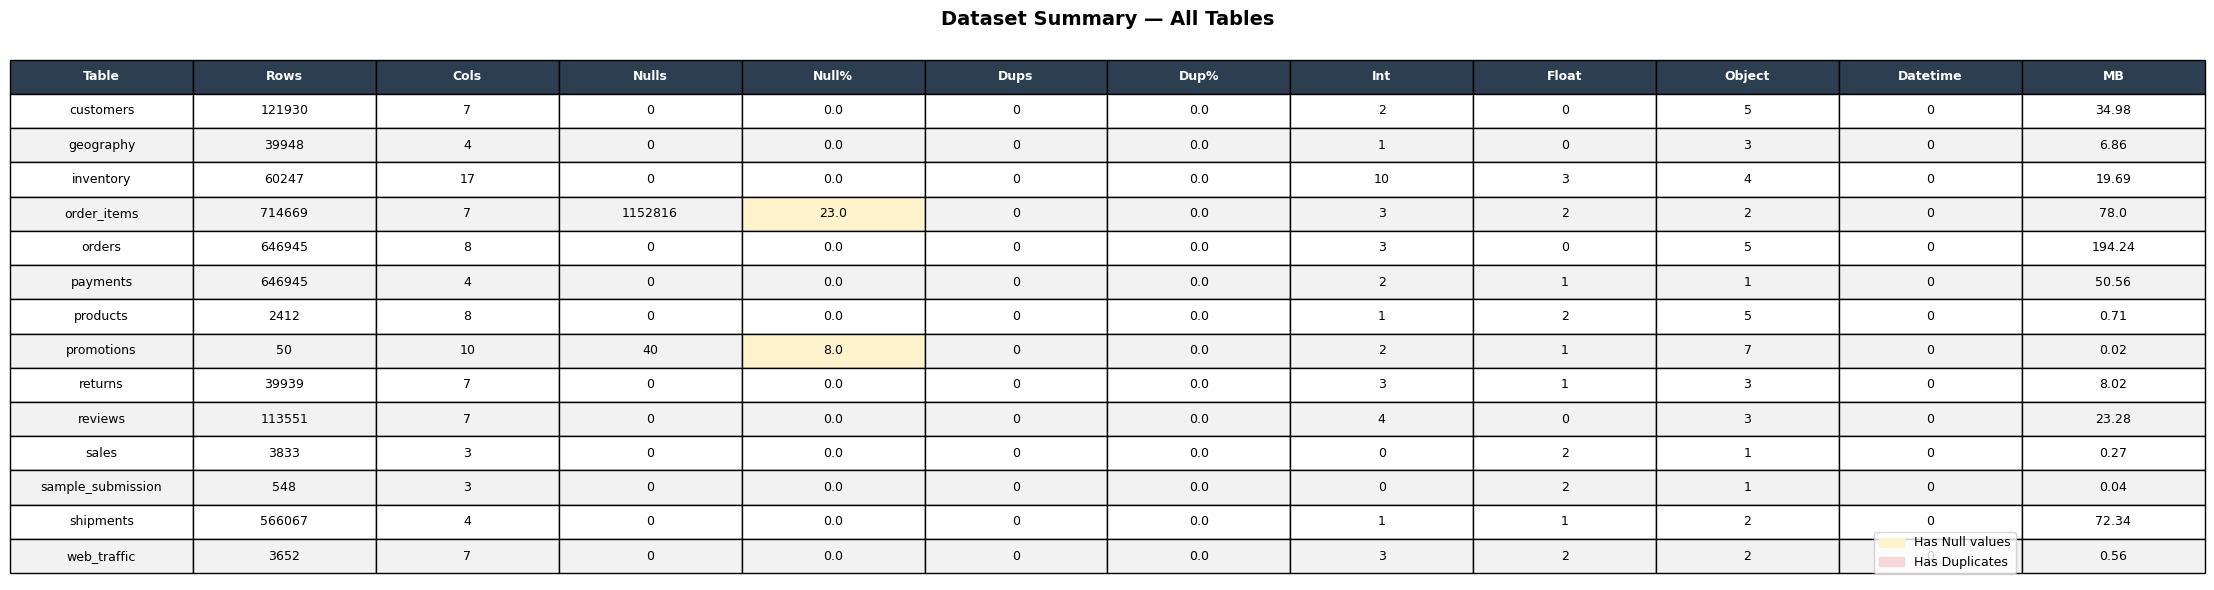

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
all_dfs = {
    "customers"        : customers,
    "geography"        : geography,
    "inventory"        : inventory,
    "order_items"      : order_items,
    "orders"           : orders,
    "payments"         : payments,
    "products"         : products,
    "promotions"       : promotions,
    "returns"          : returns,
    "reviews"          : reviews,
    "sales"            : sales,
    "sample_submission": sample_submission,
    "shipments"        : shipments,
    "web_traffic"      : web_traffic,
}

rows_list = []
for name, df in all_dfs.items():
    rows, cols   = df.shape
    nulls        = int(df.isnull().sum().sum())
    null_pct     = round(nulls / (rows * cols) * 100, 1)
    dups         = int(df.duplicated().sum())
    dup_pct      = round(dups / rows * 100, 1)
    mem          = round(df.memory_usage(deep=True).sum() / 1024**2, 2)

    # Fix: đếm dtype an toàn
    dtype_str    = df.dtypes.astype(str)
    n_int        = (dtype_str.str.contains('int')).sum()
    n_float      = (dtype_str.str.contains('float')).sum()
    n_obj        = (dtype_str == 'object').sum()
    n_date       = (dtype_str.str.contains('datetime')).sum()

    rows_list.append({
        "Table"   : name,
        "Rows"    : rows,
        "Cols"    : cols,
        "Nulls"   : nulls,
        "Null%"   : null_pct,
        "Dups"    : dups,
        "Dup%"    : dup_pct,
        "Int"     : int(n_int),
        "Float"   : int(n_float),
        "Object"  : int(n_obj),
        "Datetime": int(n_date),
        "MB"      : mem,
    })

summary_df = pd.DataFrame(rows_list)

# ============================================================
# VISUALIZE
# ============================================================
fig, ax = plt.subplots(figsize=(22, 6))
ax.axis('off')

table = ax.table(
    cellText  = summary_df.values,
    colLabels = summary_df.columns,
    cellLoc   = 'center',
    loc       = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Header
for j in range(len(summary_df.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row styles
for i in range(1, len(summary_df) + 1):
    for j, col in enumerate(summary_df.columns):
        cell = table[i, j]
        cell.set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

        if col == 'Null%' and float(summary_df.iloc[i-1]['Null%']) > 0:
            cell.set_facecolor('#fff3cd')   # vàng = có null

        if col == 'Dup%' and float(summary_df.iloc[i-1]['Dup%']) > 0:
            cell.set_facecolor('#f8d7da')   # đỏ = có duplicate

legend_patches = [
    mpatches.Patch(color='#fff3cd', label='Has Null values'),
    mpatches.Patch(color='#f8d7da', label='Has Duplicates'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.title('Dataset Summary — All Tables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('dataset_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Có giá trị null và không có giá trị trùng lặp

## Chuẩn hoá dữ liệu và xử lý missing values

In [6]:
promotions.isnull().sum()

promo_id                0
promo_name              0
promo_type              0
discount_value          0
start_date              0
end_date                0
applicable_category    40
promo_channel           0
stackable_flag          0
min_order_value         0
dtype: int64

Applicable category null nếu áp dụng tất cả

In [7]:
order_items.isnull().sum()

order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64

Cả 2 biến đều nullable

In [8]:
datetime_cols = {
    "customers"  : ["signup_date"],
    "promotions" : ["start_date", "end_date"],
    "orders"     : ["order_date"],
    "shipments"  : ["ship_date", "delivery_date"],
    "returns"    : ["return_date"],
    "reviews"    : ["review_date"],
    "inventory"  : ["snapshot_date"],
    "sales"      : ["Date"],
    "web_traffic": ["date"],
}
for table, cols in datetime_cols.items():
    for col in cols:
        if col in all_dfs[table].columns:
            all_dfs[table][col] = pd.to_datetime(all_dfs[table][col], errors='coerce')

numeric_cols = {
    "products"   : ["price", "cogs"],
    "promotions" : ["discount_value", "min_order_value", "stackable_flag"],
    "order_items": ["quantity", "unit_price", "discount_amount"],
    "payments"   : ["payment_value", "installments"],
    "shipments"  : ["shipping_fee"],
    "returns"    : ["return_quantity", "refund_amount"],
    "reviews"    : ["rating"],
    "inventory"  : ["stock_on_hand", "units_received", "units_sold",
                    "stockout_days", "days_of_supply", "fill_rate",
                    "sell_through_rate", "stockout_flag",
                    "overstock_flag", "reorder_flag"],
    "web_traffic": ["sessions", "unique_visitors", "page_views",
                    "bounce_rate", "avg_session_duration_sec"],
    "sales"      : ["Revenue", "COGS"],
}
for table, cols in numeric_cols.items():
    for col in cols:
        if col in all_dfs[table].columns:
            all_dfs[table][col] = pd.to_numeric(all_dfs[table][col], errors='coerce')

order_items['promo_id']   = order_items['promo_id'].fillna('NO_PROMO')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('NO_PROMO')

promotions['applicable_category'] = promotions['applicable_category'].fillna('ALL')
promotions['promo_channel']       = promotions['promo_channel'].fillna('ALL')
promotions['min_order_value']     = promotions['min_order_value'].fillna(0.0)

customers['gender']               = customers['gender'].fillna('Unknown')
customers['age_group']            = customers['age_group'].fillna('Unknown')
customers['acquisition_channel']  = customers['acquisition_channel'].fillna('Unknown')

all_dfs['order_items'] = order_items
all_dfs['promotions']  = promotions
all_dfs['customers']   = customers

category_cols = {
    "customers"  : ["gender", "age_group", "acquisition_channel"],
    "geography"  : ["city", "region", "district"],
    "products"   : ["category", "segment", "size", "color"],
    "promotions" : ["promo_type", "promo_channel", "applicable_category"],
    "orders"     : ["order_status", "payment_method", "device_type", "order_source"],
    "payments"   : ["payment_method"],
    "returns"    : ["return_reason"],
    "inventory"  : ["category", "segment"],
    "web_traffic": ["traffic_source"],
}
for table, cols in category_cols.items():
    for col in cols:
        if col in all_dfs[table].columns:
            all_dfs[table][col] = all_dfs[table][col].astype('category')


# Update lại biến
customers   = all_dfs["customers"]
geography   = all_dfs["geography"]
inventory   = all_dfs["inventory"]
order_items = all_dfs["order_items"]
orders      = all_dfs["orders"]
payments    = all_dfs["payments"]
products    = all_dfs["products"]
promotions  = all_dfs["promotions"]
returns     = all_dfs["returns"]
reviews     = all_dfs["reviews"]
sales       = all_dfs["sales"]
shipments   = all_dfs["shipments"]
web_traffic = all_dfs["web_traffic"]
print("📊 Kết quả sau cleaning:")
for name, df in all_dfs.items():
    print(f"  {name:20s} | nulls: {df.isnull().sum().sum()} | dups: {df.duplicated().sum()}")

📊 Kết quả sau cleaning:
  customers            | nulls: 0 | dups: 0
  geography            | nulls: 0 | dups: 0
  inventory            | nulls: 0 | dups: 0
  order_items          | nulls: 0 | dups: 0
  orders               | nulls: 0 | dups: 0
  payments             | nulls: 0 | dups: 0
  products             | nulls: 0 | dups: 0
  promotions           | nulls: 0 | dups: 0
  returns              | nulls: 0 | dups: 0
  reviews              | nulls: 0 | dups: 0
  sales                | nulls: 0 | dups: 0
  sample_submission    | nulls: 0 | dups: 0
  shipments            | nulls: 0 | dups: 0
  web_traffic          | nulls: 0 | dups: 0


In [9]:
order_items.isnull().sum()

order_id           0
product_id         0
quantity           0
unit_price         0
discount_amount    0
promo_id           0
promo_id_2         0
dtype: int64

In [10]:
promotions.isnull().sum()

promo_id               0
promo_name             0
promo_type             0
discount_value         0
start_date             0
end_date               0
applicable_category    0
promo_channel          0
stackable_flag         0
min_order_value        0
dtype: int64

(0.0, 1.0, 0.0, 1.0)

Text(0.5, 1.0, 'Dataset Summary — After Cleaning')

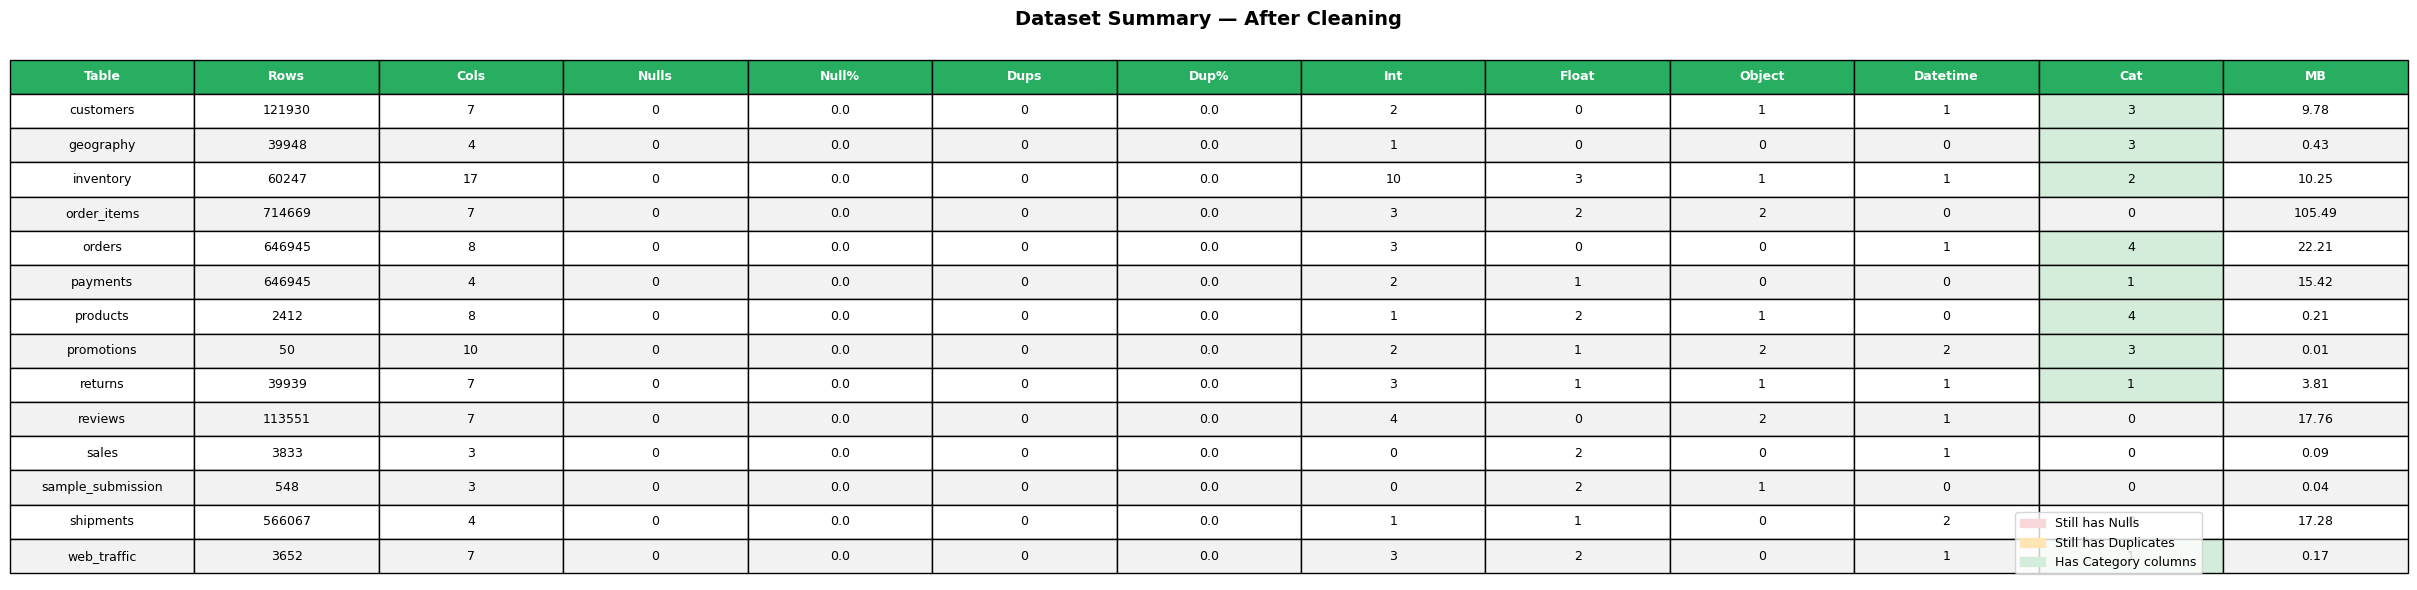

In [11]:
rows_list = []
for name, df in all_dfs.items():
    rows, cols   = df.shape
    nulls        = int(df.isnull().sum().sum())
    null_pct     = round(nulls / (rows * cols) * 100, 1)
    dups         = int(df.duplicated().sum())
    dup_pct      = round(dups / rows * 100, 1)
    mem          = round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    dtype_str    = df.dtypes.astype(str)
    n_int        = int((dtype_str.str.contains('int')).sum())
    n_float      = int((dtype_str.str.contains('float')).sum())
    n_obj        = int((dtype_str == 'object').sum())
    n_date       = int((dtype_str.str.contains('datetime')).sum())
    n_cat        = int((dtype_str == 'category').sum())

    rows_list.append({
        "Table"   : name,   "Rows"    : rows,
        "Cols"    : cols,   "Nulls"   : nulls,
        "Null%"   : null_pct, "Dups"  : dups,
        "Dup%"    : dup_pct,  "Int"   : n_int,
        "Float"   : n_float,  "Object": n_obj,
        "Datetime": n_date,   "Cat"   : n_cat,
        "MB"      : mem,
    })

summary_clean = pd.DataFrame(rows_list)

fig, ax = plt.subplots(figsize=(24, 6))
ax.axis('off')

table = ax.table(
    cellText  = summary_clean.values,
    colLabels = summary_clean.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Header
for j in range(len(summary_clean.columns)):
    table[0, j].set_facecolor('#27ae60')   # xanh lá = đã clean
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row styles
for i in range(1, len(summary_clean) + 1):
    for j, col in enumerate(summary_clean.columns):
        cell = table[i, j]
        cell.set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

        # Vẫn còn null → đỏ
        if col == 'Null%' and float(summary_clean.iloc[i-1]['Null%']) > 0:
            cell.set_facecolor('#f8d7da')

        # Vẫn còn dup → cam
        if col == 'Dup%' and float(summary_clean.iloc[i-1]['Dup%']) > 0:
            cell.set_facecolor('#ffe5b4')

        # Cat > 0 → xanh nhạt (đã categorize thành công)
        if col == 'Cat' and int(summary_clean.iloc[i-1]['Cat']) > 0:
            cell.set_facecolor('#d4edda')

legend_patches = [
    mpatches.Patch(color='#f8d7da', label='Still has Nulls'),
    mpatches.Patch(color='#ffe5b4', label='Still has Duplicates'),
    mpatches.Patch(color='#d4edda', label='Has Category columns'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.title('Dataset Summary — After Cleaning', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('dataset_summary_clean.png', dpi=150, bbox_inches='tight')
plt.show()

## EXPLORARY DATA ANALYSIS

In [27]:
products.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [25]:
customers.describe()

,customer_id,zip,signup_date,signup_year
count,121930.000000,121930.000000,121930,121930.000000
mean,78736.898663,50990.165595,2019-05-02 06:41:34.637906688,2018.817272
min,1.000000,1001.000000,2012-01-17 00:00:00,2012.000000
25%,39343.500000,28689.250000,2017-06-27 00:00:00,2017.000000
50%,78784.500000,49835.000000,2019-10-12 00:00:00,2019.000000
75%,118156.750000,73488.000000,2021-07-11 00:00:00,2021.000000
max,157563.000000,99950.000000,2022-12-31 00:00:00,2022.000000
std,45492.202886,26871.914605,NaN,2.584273


In [28]:
promotions.describe()

,discount_value,start_date,end_date,stackable_flag,min_order_value,promo_year,duration_days,promo_month
count,50.000000,50,50,50.000000,50.000000,50.000000,50.000000,50.000000
mean,18.500000,2017-11-29 02:52:48,2018-01-01 15:50:24,0.240000,46000.000000,2017.400000,33.540000,6.400000
min,10.000000,2013-01-31 00:00:00,2013-03-01 00:00:00,0.000000,0.000000,2013.000000,29.000000,1.000000
25%,12.000000,2015-07-02 06:00:00,2015-08-01 12:00:00,0.000000,0.000000,2015.000000,30.000000,3.000000
50%,16.500000,2017-10-09 00:00:00,2017-11-17 00:00:00,0.000000,0.000000,2017.000000,30.500000,6.500000
75%,20.000000,2020-05-29 18:00:00,2020-06-28 00:00:00,0.000000,100000.000000,2020.000000,34.000000,8.000000
max,50.000000,2022-11-18 00:00:00,2022-12-31 00:00:00,1.000000,200000.000000,2022.000000,45.000000,11.000000
std,11.241777,NaN,NaN,0.431419,66116.779802,2.899683,5.807138,3.200765


In [33]:
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   zip       39948 non-null  int64   
 1   city      39948 non-null  category
 2   region    39948 non-null  category
 3   district  39948 non-null  category
dtypes: category(3), int64(1)
memory usage: 432.1 KB


In [34]:
geography.head(10)

,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13
5,15206,Lao Cai,East,District #13
6,15207,Hai Phong,East,District #13
7,15208,Viet Tri,East,District #13
8,15209,Ha Long,East,District #13
9,15210,Hai Phong,East,District #13


In [32]:
geography.describe()

,zip
count,39948.000000
mean,50895.084735
std,27042.257341
min,1.000000
25%,28279.500000
50%,49876.500000
75%,73526.250000
max,99950.000000


In [36]:
orders.head(10)

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,order_year,order_month
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2012,7
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,2012,7
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,2012,7
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,2012,7
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,2012,7
5,7,2012-07-06,57820,2886,delivered,credit_card,tablet,organic_search,2012,7
6,8,2012-07-06,57818,2886,delivered,credit_card,mobile,email_campaign,2012,7
7,9,2012-07-06,49102,5262,delivered,apple_pay,tablet,paid_search,2012,7
8,10,2012-07-06,49101,5262,delivered,paypal,desktop,organic_search,2012,7
9,13,2012-07-06,40638,7456,delivered,credit_card,tablet,social_media,2012,7


In [35]:
orders.describe()

,order_id,order_date,customer_id,zip,order_year,order_month
count,646945.000000,646945,646945.000000,646945.000000,646945.000000,646945.000000
mean,417189.470332,2016-11-28 05:46:39.463323904,84906.203535,55410.740423,2016.410148,6.471145
min,1.000000,2012-07-04 00:00:00,1.000000,1001.000000,2012.000000,1.000000
25%,208728.000000,2014-08-05 00:00:00,41336.000000,30904.000000,2014.000000,4.000000
50%,417211.000000,2016-07-25 00:00:00,87279.000000,54129.000000,2016.000000,6.000000
75%,625628.000000,2018-08-27 00:00:00,133282.000000,83301.000000,2018.000000,9.000000
max,834397.000000,2022-12-31 00:00:00,157563.000000,99950.000000,2022.000000,12.000000
std,240785.704463,NaN,48446.922752,28876.471824,2.765174,3.091908


In [37]:
order_items.head(10)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO
5,7,1934,6,1633.49,0.0,NO_PROMO,NO_PROMO
6,8,1934,6,1602.92,0.0,NO_PROMO,NO_PROMO
7,8,1935,4,1642.51,0.0,NO_PROMO,NO_PROMO
8,9,1432,8,4049.64,0.0,NO_PROMO,NO_PROMO
9,10,1431,5,3977.37,0.0,NO_PROMO,NO_PROMO


In [39]:
payments.head(10)

,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1
5,7,credit_card,9800.94,12
6,8,credit_card,16187.56,6
7,9,apple_pay,32397.12,12
8,10,paypal,19886.85,1
9,13,credit_card,36037.68,3


In [40]:
payments.describe()

,order_id,payment_value,installments
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,24238.334426,3.448319
std,240785.704463,22378.475324,3.119582
min,1.000000,389.740000,1.000000
25%,208728.000000,7681.060000,1.000000
50%,417211.000000,17229.440000,3.000000
75%,625628.000000,33706.350000,6.000000
max,834397.000000,331570.400000,12.000000


In [38]:
payments.describe()

,order_id,payment_value,installments
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,24238.334426,3.448319
std,240785.704463,22378.475324,3.119582
min,1.000000,389.740000,1.000000
25%,208728.000000,7681.060000,1.000000
50%,417211.000000,17229.440000,3.000000
75%,625628.000000,33706.350000,6.000000
max,834397.000000,331570.400000,12.000000


In [41]:
shipments.head(10)

,order_id,ship_date,delivery_date,shipping_fee,delivery_days
0,1,2012-07-07,2012-07-11,1.37,4
1,2,2012-07-06,2012-07-10,2.60,4
2,3,2012-07-04,2012-07-07,2.38,3
3,4,2012-07-05,2012-07-11,2.49,6
4,6,2012-07-09,2012-07-16,25.79,7
5,7,2012-07-06,2012-07-12,1.31,6
6,8,2012-07-06,2012-07-11,0.43,5
7,9,2012-07-07,2012-07-13,0.18,6
8,10,2012-07-07,2012-07-13,0.86,6
9,13,2012-07-09,2012-07-12,2.44,3


In [42]:
shipments.describe()

,order_id,ship_date,delivery_date,shipping_fee,delivery_days
count,566067.000000,566067,566067,566067.000000,566067.000000
mean,415816.869664,2016-11-22 15:48:56.813486336,2016-11-27 03:47:48.510618112,4.962857,4.499209
min,1.000000,2012-07-04 00:00:00,2012-07-06 00:00:00,0.000000,2.000000
25%,208192.500000,2014-08-05 00:00:00,2014-08-10 00:00:00,0.870000,3.000000
50%,415866.000000,2016-07-22 00:00:00,2016-07-27 00:00:00,1.730000,4.000000
75%,623218.500000,2018-08-17 00:00:00,2018-08-22 00:00:00,2.600000,6.000000
max,834325.000000,2022-12-29 00:00:00,2022-12-31 00:00:00,32.000000,7.000000
std,240007.311562,NaN,NaN,8.887355,1.707018


In [43]:
returns.head(10)

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76
5,RET-000006,59,671,2012-07-19,defective,1,10086.33
6,RET-000007,67,604,2012-07-16,wrong_size,1,5713.22
7,RET-000008,102,467,2012-07-17,defective,1,9724.09
8,RET-000010,108,635,2012-07-30,wrong_size,5,43387.54
9,RET-000012,132,103,2012-07-29,changed_mind,2,19200.35


In [44]:
returns.describe()

,order_id,product_id,return_date,return_quantity,refund_amount
count,39939.000000,39939.000000,39939,39939.000000,39939.000000
mean,409061.984176,1244.232730,2016-11-11 22:20:33.621272576,2.743834,12784.458964
min,2.000000,3.000000,2012-07-11 00:00:00,1.000000,458.810000
25%,202651.000000,702.000000,2014-08-05 00:00:00,1.000000,3573.395000
50%,404254.000000,992.000000,2016-07-06 00:00:00,2.000000,7888.880000
75%,615620.000000,2048.000000,2018-08-08 00:00:00,4.000000,16881.990000
max,833351.000000,2412.000000,2022-12-31 00:00:00,8.000000,160937.940000
std,240063.904576,691.747822,NaN,1.828260,14092.150154


In [61]:
reviews.head(10)

,review_id,order_id,product_id,customer_id,review_date,rating,review_title,review_year
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend,2012
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied,2012
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality,2012
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality,2012
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall,2012
5,REV-0000008,20,2241,42962,2012-08-12,5,Great quality,2012
6,REV-0000009,23,1041,12213,2012-07-19,5,Very satisfied,2012
7,REV-0000010,24,671,13426,2012-08-09,4,Solid choice,2012
8,REV-0000011,28,396,9473,2012-07-27,5,Very satisfied,2012
9,REV-0000012,49,671,39696,2012-07-17,5,Highly recommend,2012


In [26]:
sales.describe()

,Date,Revenue,COGS,year,month,quarter,Profit,Margin%
count,3833,3.833000e+03,3.833000e+03,3833.000000,3833.000000,3833.000000,3.833000e+03,3833.000000
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06,2017.240543,6.665797,2.555961,5.914495e+05,12.539306
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05,2012.000000,1.000000,1.000000,-2.567312e+06,-57.457973
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06,2015.000000,4.000000,2.000000,2.292740e+05,8.261275
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06,2017.000000,7.000000,3.000000,5.445544e+05,17.830046
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06,2020.000000,10.000000,4.000000,8.760810e+05,20.288745
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07,2022.000000,12.000000,4.000000,4.369414e+06,28.691554
std,NaN,2.624840e+06,2.219789e+06,3.036754,3.446462,1.116194,6.661960e+05,12.735614


In [63]:
inventory.head(10)

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,inv_year,inv_month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,2016,5
5,2016-06-30,3,37,8,7,2,158.6,0.9333,1,1,0,0.1591,DragonWear MA-03,Casual,All-weather,2016,6,2016,6
6,2016-07-31,3,39,11,9,2,130.0,0.9333,1,1,0,0.1875,DragonWear MA-03,Casual,All-weather,2016,7,2016,7
7,2016-08-31,3,39,4,4,0,292.5,1.0000,0,1,0,0.0930,DragonWear MA-03,Casual,All-weather,2016,8,2016,8
8,2016-09-30,3,40,7,6,0,200.0,1.0000,0,1,0,0.1304,DragonWear MA-03,Casual,All-weather,2016,9,2016,9
9,2016-10-31,3,41,7,6,1,205.0,0.9667,1,1,0,0.1277,DragonWear MA-03,Casual,All-weather,2016,10,2016,10


In [64]:
web_traffic.head(10)

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,wt_year
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,2013
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search,2013
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct,2013
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct,2013
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral,2013
5,2013-01-06,9545,6992,47160,0.00438,263.6,social_media,2013
6,2013-01-07,10203,7354,32749,0.00443,252.1,organic_search,2013
7,2013-01-08,9456,7459,31482,0.00440,192.4,paid_search,2013
8,2013-01-09,9162,7108,46717,0.00409,312.8,organic_search,2013
9,2013-01-10,9887,7878,38472,0.00544,285.4,organic_search,2013


<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap - Sales')

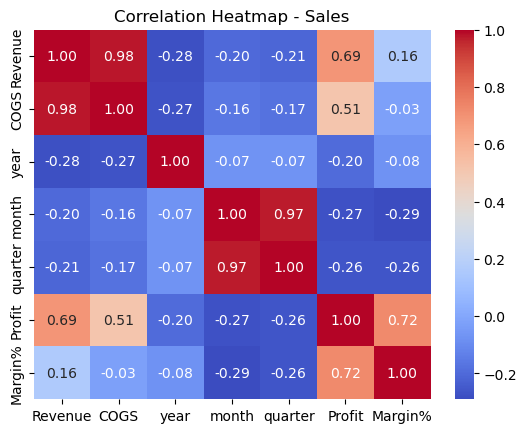

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chỉ lấy cột numeric
corr = sales.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Sales")
plt.show()

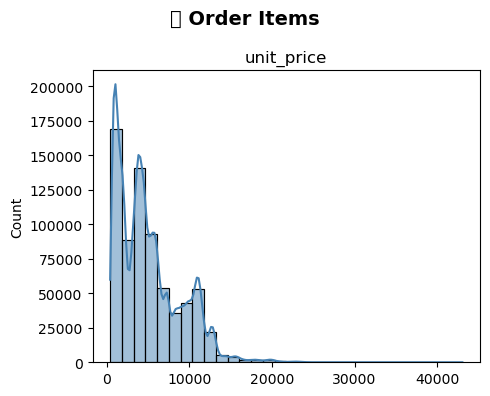

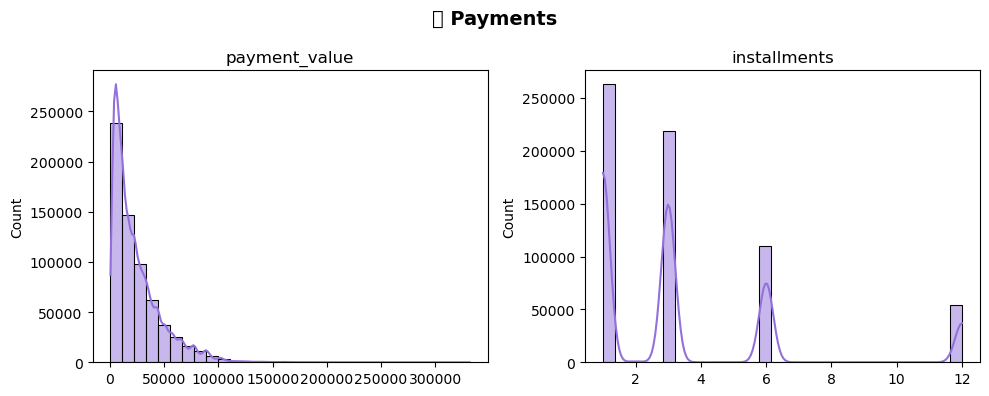

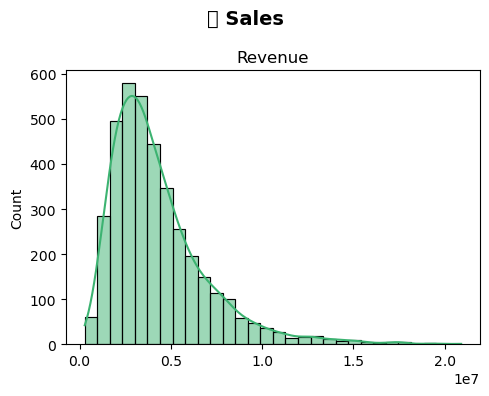

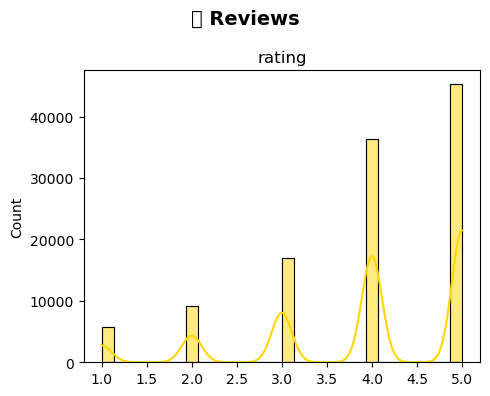

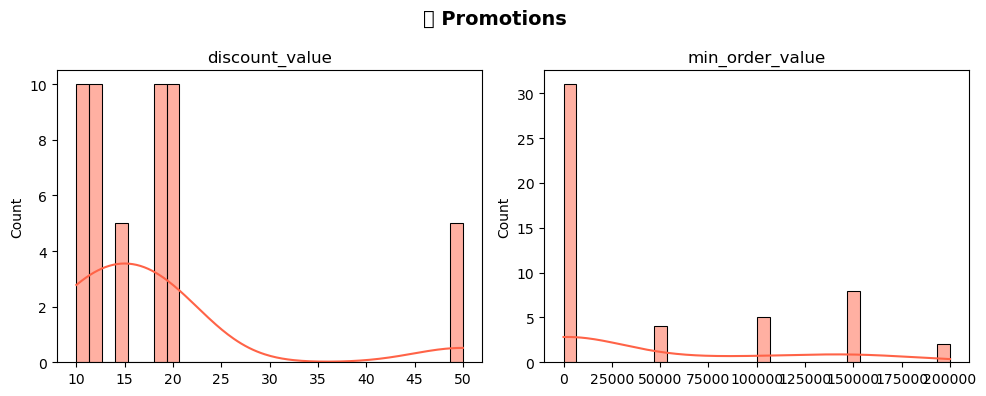

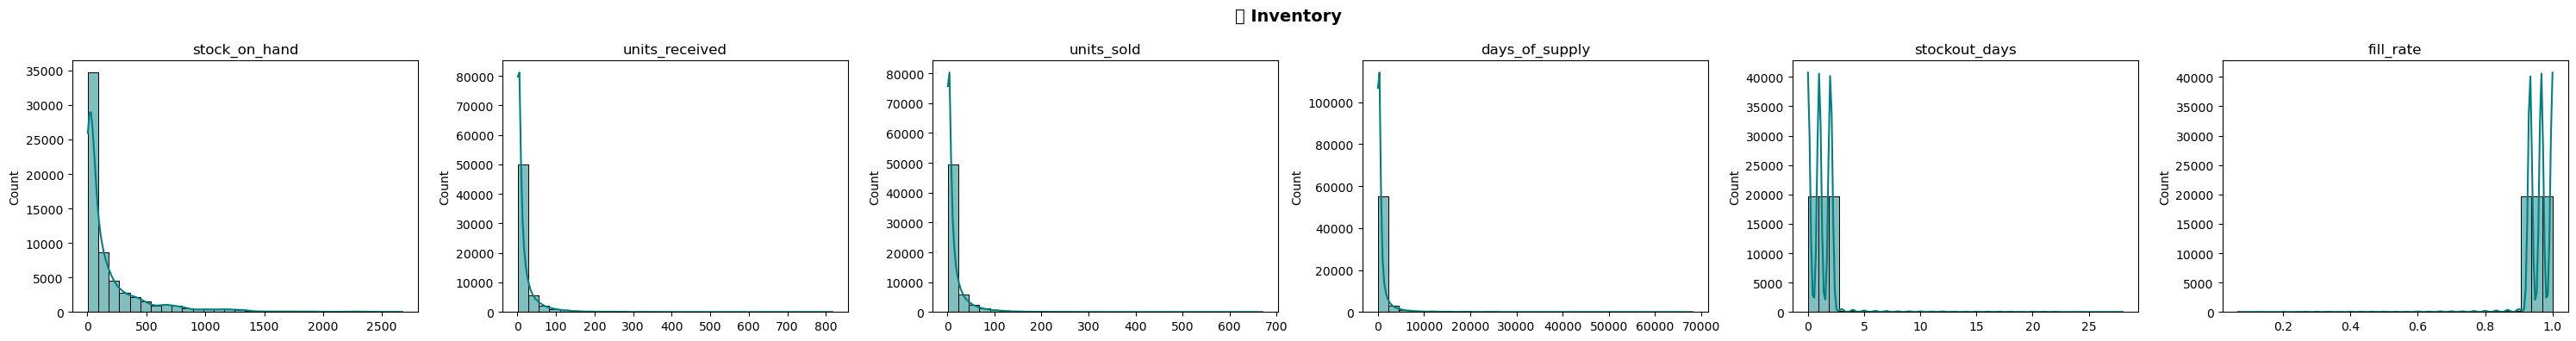

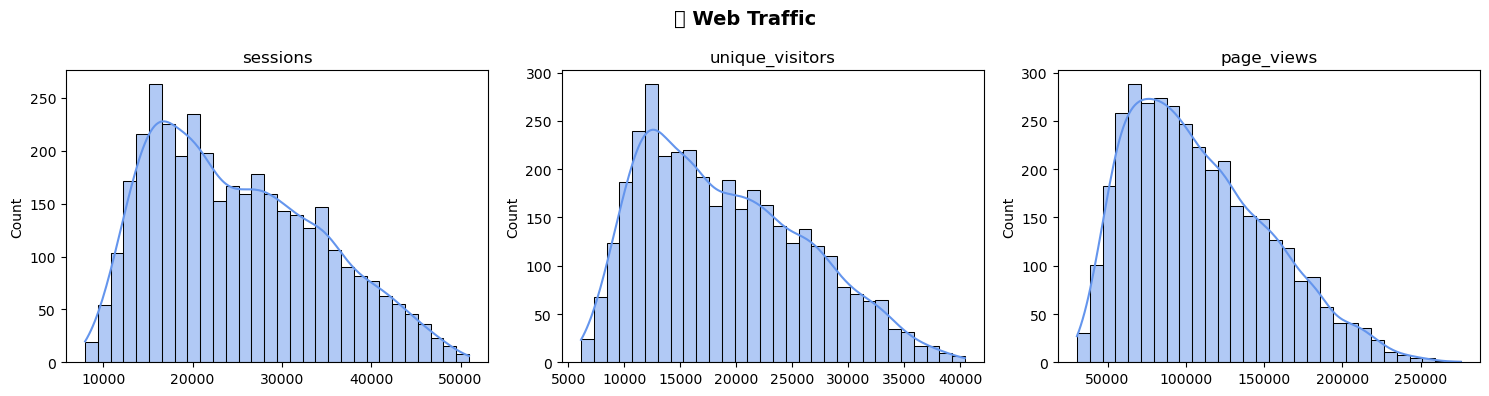

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_histograms(df, cols, title, color='steelblue'):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        sns.histplot(df[col].dropna(), bins=30, ax=ax, color=color, kde=True)
        ax.set_title(col)
        ax.set_xlabel('')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_boxplots(df, cols, title, color='steelblue'):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col].dropna(), ax=ax, color=color)
        ax.set_title(col)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================
# HISTOGRAM
# ============================================================

# --- ORDER ITEMS ---
plot_histograms(order_items,
                ['unit_price'],
                '📦 Order Items', color='steelblue')

# --- PAYMENTS ---
plot_histograms(payments,
                ['payment_value', 'installments'],
                '💳 Payments', color='mediumpurple')

# --- SALES ---
plot_histograms(sales,
                ['Revenue'],
                '💰 Sales', color='mediumseagreen')

# --- REVIEWS ---
plot_histograms(reviews,
                ['rating'],
                '⭐ Reviews', color='gold')

# --- PROMOTIONS ---
plot_histograms(promotions,
                ['discount_value', 'min_order_value'],
                '🎁 Promotions', color='tomato')

# --- INVENTORY ---
plot_histograms(inventory,
                ['stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'stockout_days', 'fill_rate'],
                '🏭 Inventory', color='teal')

# --- WEB TRAFFIC ---
plot_histograms(web_traffic,
                ['sessions', 'unique_visitors', 'page_views'],
                '🌐 Web Traffic', color='cornflowerblue')


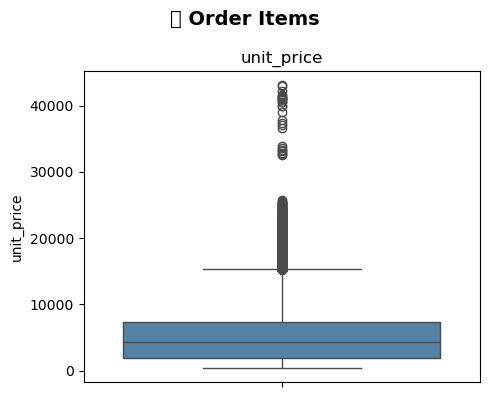

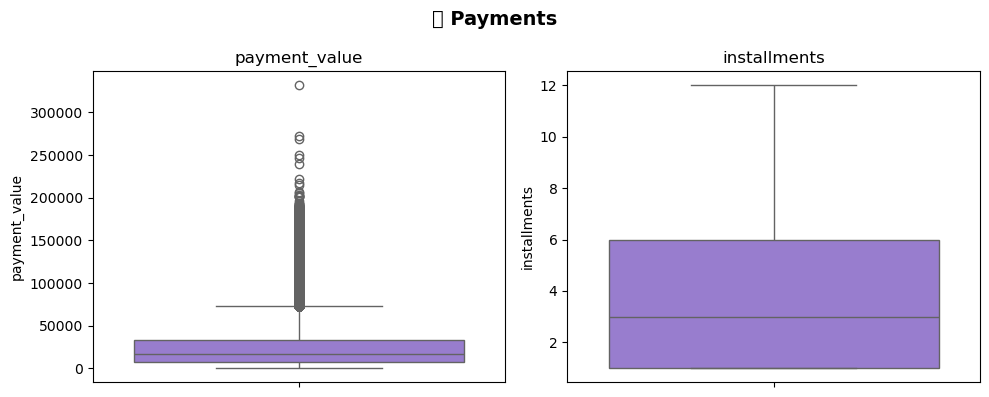

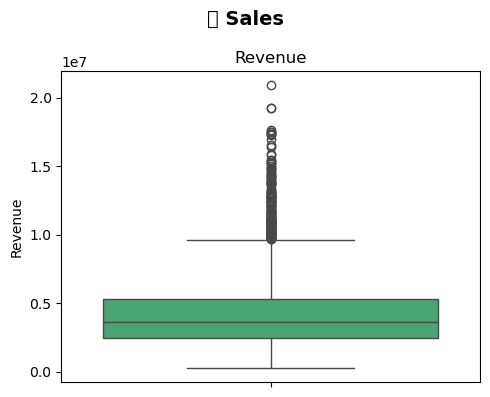

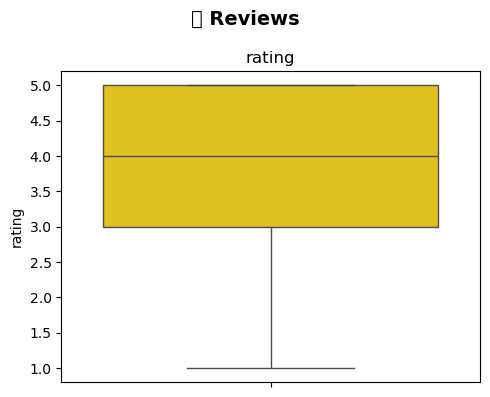

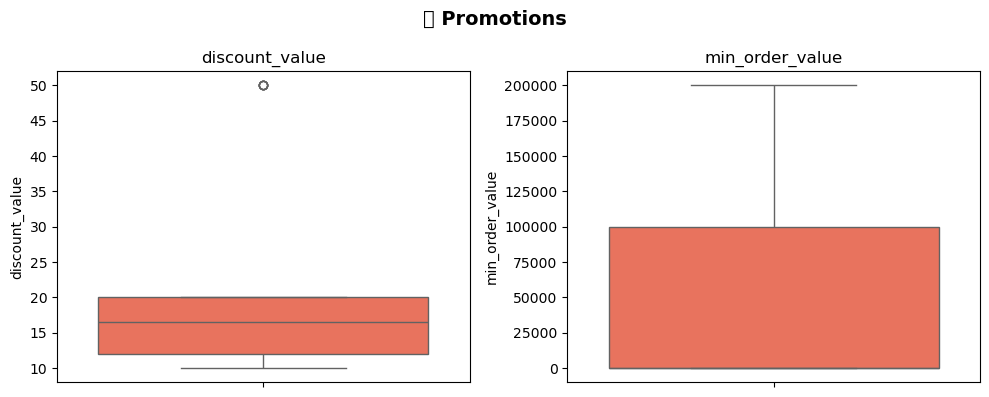

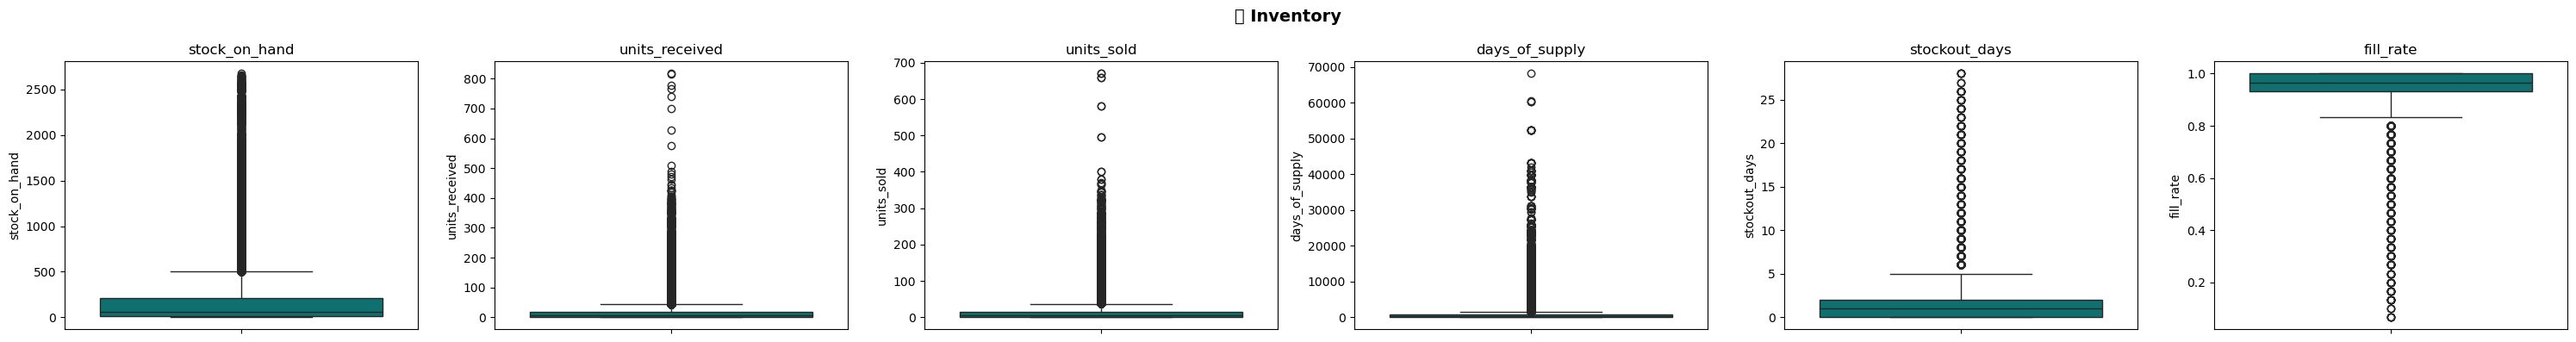

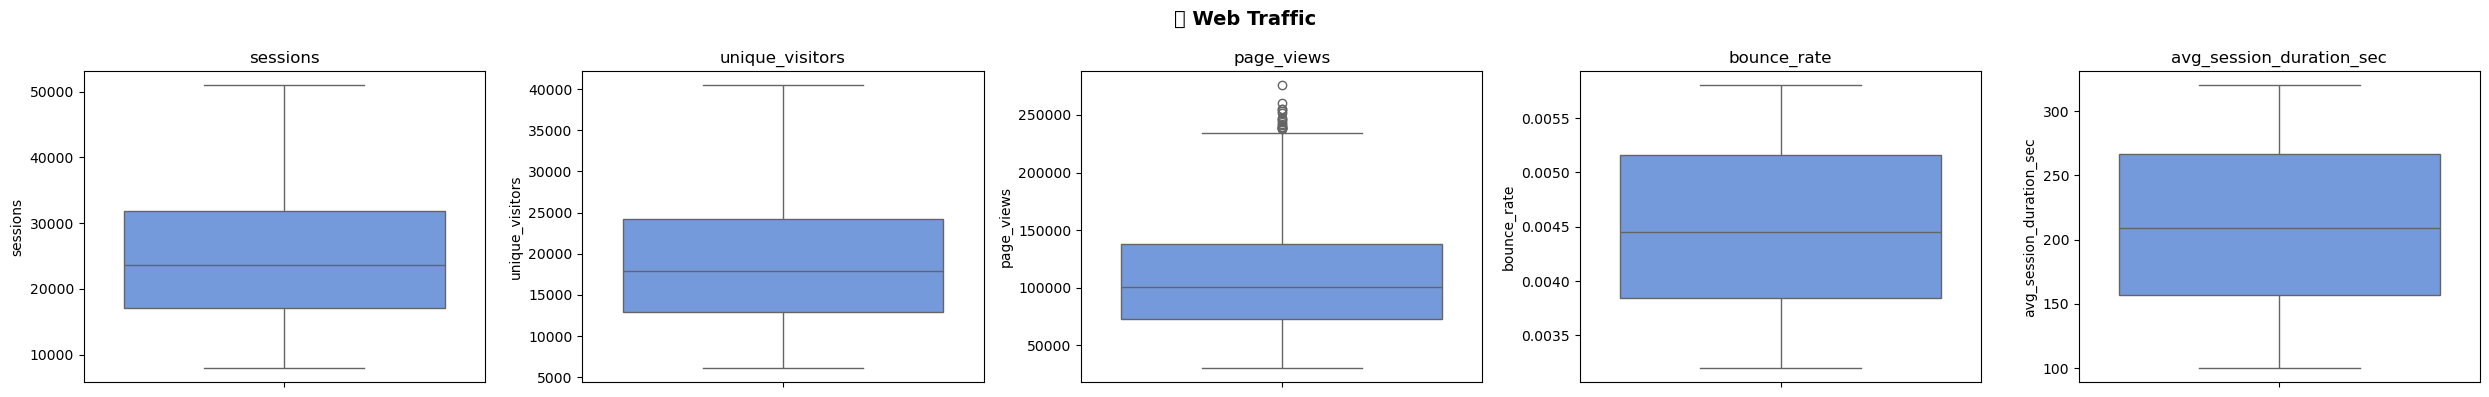

In [69]:
# ============================================================
# BOXPLOT - FULL DATASET
# ============================================================

def plot_boxplots(df, cols, title, color='steelblue'):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col].dropna(), ax=ax, color=color)
        ax.set_title(col)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- ORDER ITEMS ---
plot_boxplots(order_items,
              ['unit_price'],
              '📦 Order Items', color='steelblue')

# --- PAYMENTS ---
plot_boxplots(payments,
              ['payment_value', 'installments'],
              '💳 Payments', color='mediumpurple')

# --- SALES ---
plot_boxplots(sales,
              ['Revenue'],
              '💰 Sales', color='mediumseagreen')

# --- REVIEWS ---
plot_boxplots(reviews,
              ['rating'],
              '⭐ Reviews', color='gold')

# --- PROMOTIONS ---
plot_boxplots(promotions,
              ['discount_value', 'min_order_value'],
              '🎁 Promotions', color='tomato')

# --- INVENTORY ---
plot_boxplots(inventory,
              ['stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'stockout_days', 'fill_rate'],
              '🏭 Inventory', color='teal')

# --- WEB TRAFFIC ---
plot_boxplots(web_traffic,
              ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec'],
              '🌐 Web Traffic', color='cornflowerblue')

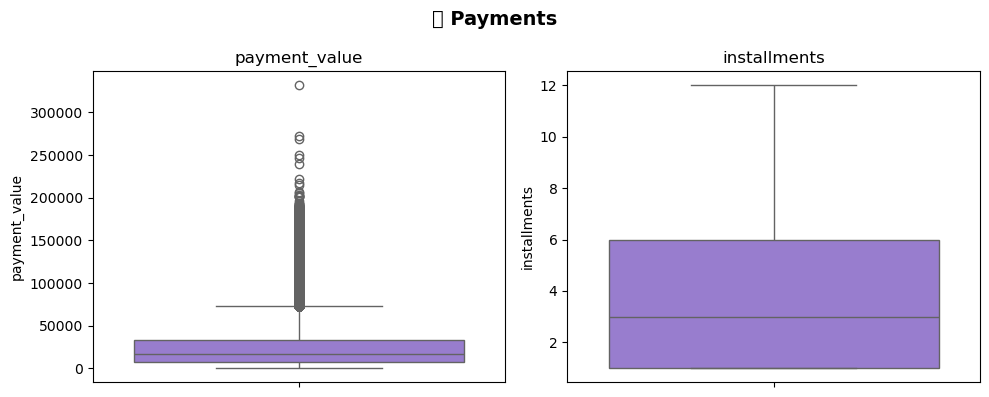

In [77]:
plot_boxplots(payments,
              ['payment_value', 'installments'],
              '💳 Payments', color='mediumpurple')

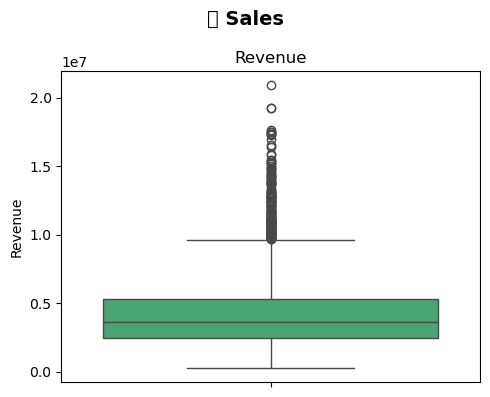

In [78]:
# --- SALES ---
plot_boxplots(sales,
              ['Revenue'],
              '💰 Sales', color='mediumseagreen')

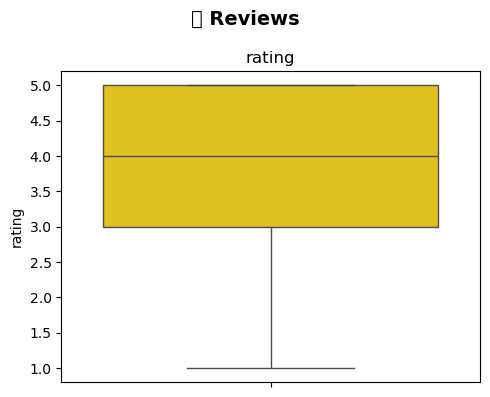

In [79]:
# --- REVIEWS ---
plot_boxplots(reviews,
              ['rating'],
              '⭐ Reviews', color='gold')



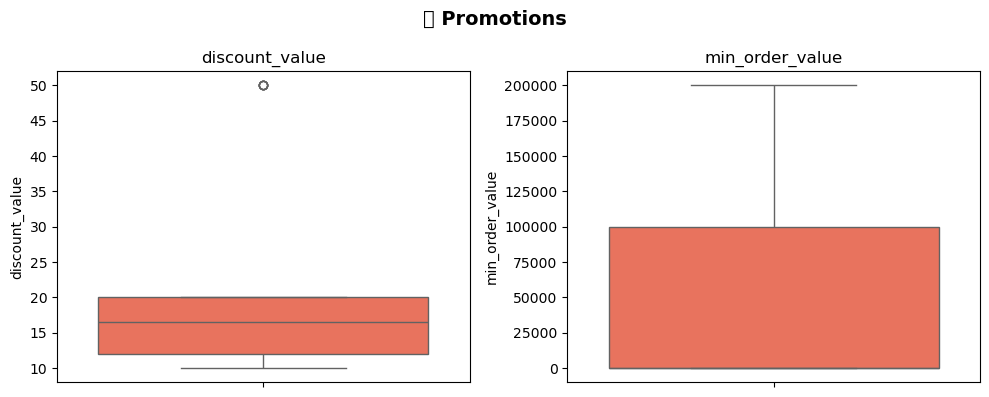

In [81]:
#--- PROMOTIONS ---
plot_boxplots(promotions,
              ['discount_value', 'min_order_value'],
              '🎁 Promotions', color='tomato')


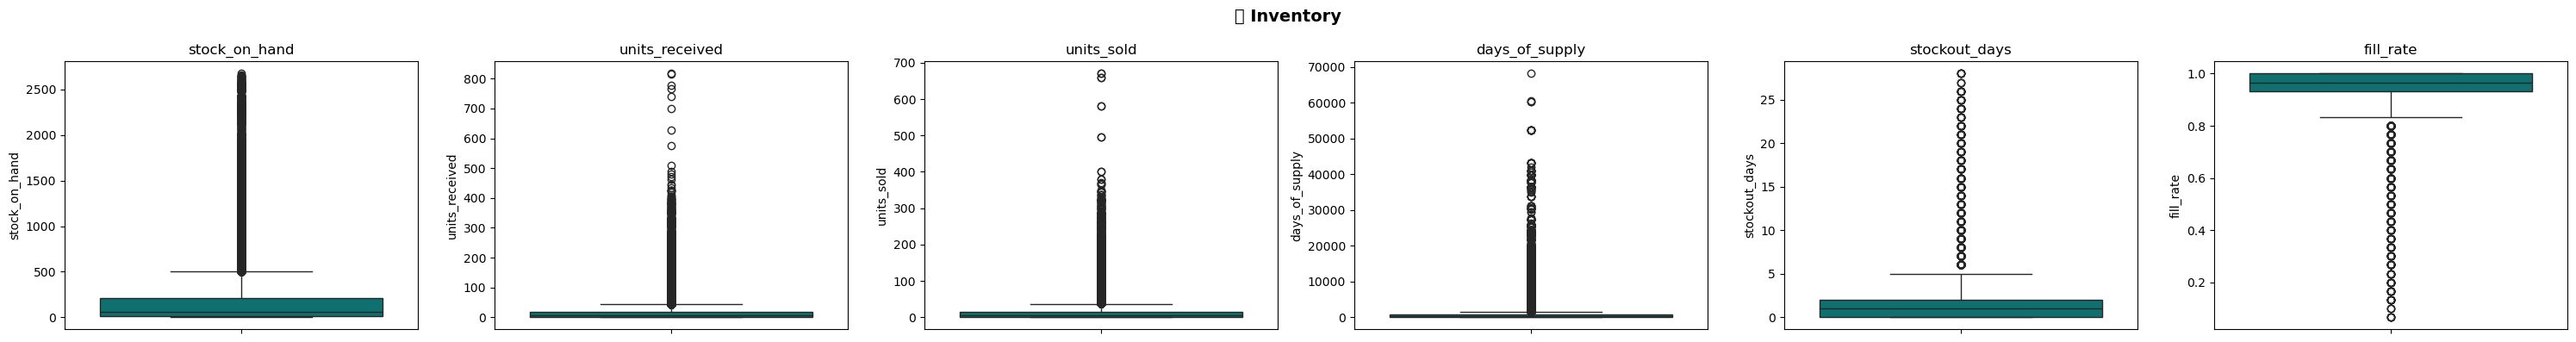

In [82]:
# --- INVENTORY ---
plot_boxplots(inventory,
              ['stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'stockout_days', 'fill_rate'],
              '🏭 Inventory', color='teal')


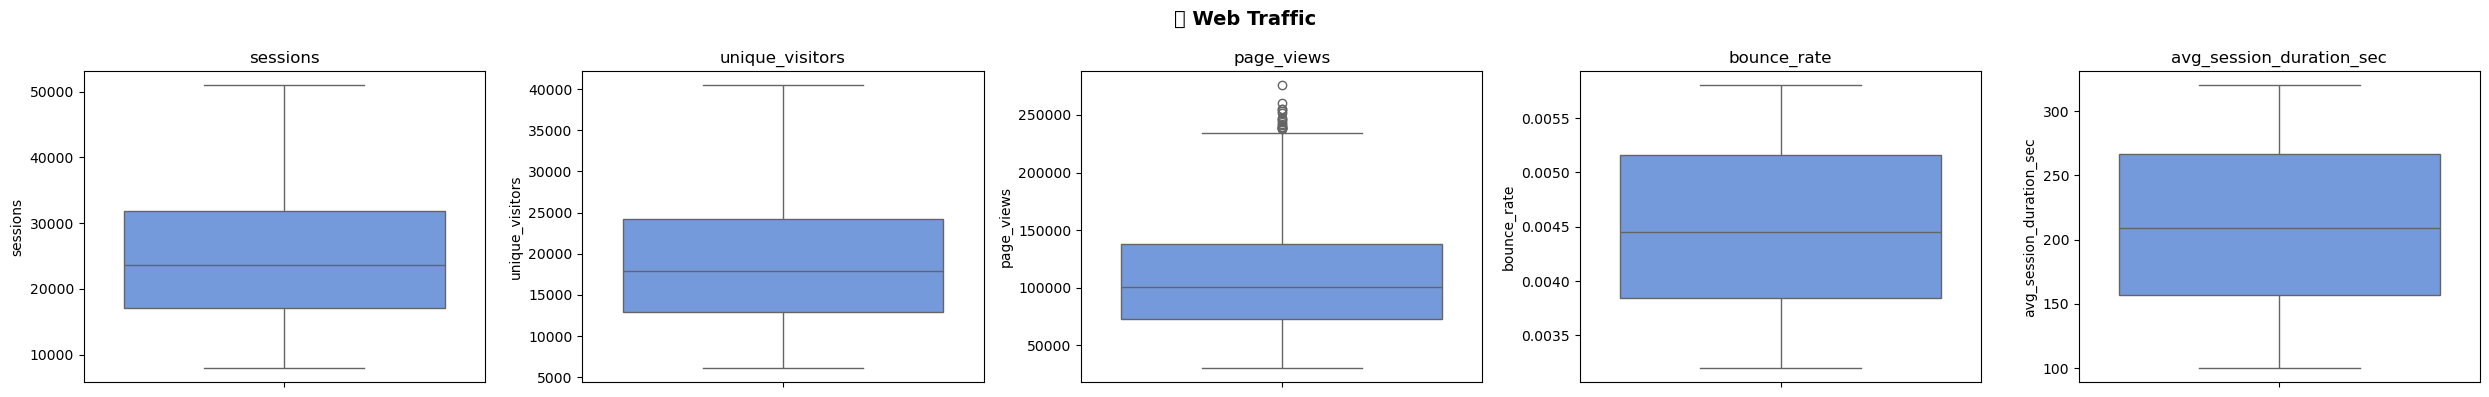

In [83]:
# --- WEB TRAFFIC ---
plot_boxplots(web_traffic,
              ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec'],
              '🌐 Web Traffic', color='cornflowerblue')

In [72]:
# Check thử outlier
order_items[order_items['unit_price'] > 30000]

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
486968,560153,347,4,41319.56,0.00,NO_PROMO,NO_PROMO
487772,561096,347,5,40546.16,0.00,NO_PROMO,NO_PROMO
489559,563097,347,6,41077.20,0.00,NO_PROMO,NO_PROMO
519325,598739,347,4,42268.78,0.00,NO_PROMO,NO_PROMO
520793,600551,347,1,42937.31,0.00,NO_PROMO,NO_PROMO
524503,605053,347,2,39988.20,0.00,NO_PROMO,NO_PROMO
524565,605128,347,6,41672.48,0.00,NO_PROMO,NO_PROMO
524742,605348,347,4,40524.85,0.00,NO_PROMO,NO_PROMO
524764,605374,347,2,43056.00,0.00,NO_PROMO,NO_PROMO
526638,607630,347,4,32884.85,23677.09,PROMO-0028,NO_PROMO


## Visualization

📊 DOANH THU THEO NĂM
 year      Revenue         COGS       Profit  Margin%  Rev_Growth%
 2012 7.414977e+08 5.874619e+08 154035824.21     20.8          NaN
 2013 1.657169e+09 1.465980e+09 191189314.07     11.5   123.489474
 2014 1.871846e+09 1.574607e+09 297238425.91     15.9    12.954407
 2015 1.889934e+09 1.665442e+09 224492009.50     11.9     0.966316
 2016 2.104641e+09 1.780559e+09 324081284.85     15.4    11.360549
 2017 1.911164e+09 1.694386e+09 216778531.74     11.3    -9.192845
 2018 1.850122e+09 1.542176e+09 307946689.94     16.6    -3.193962
 2019 1.136801e+09 1.005203e+09 131598557.79     11.6   -38.555341
 2020 1.054512e+09 8.860851e+08 168427061.16     16.0    -7.238668
 2021 1.043040e+09 9.411301e+08 101909699.47      9.8    -1.087929
 2022 1.169749e+09 1.020420e+09 149328667.72     12.8    12.148051

📦 TỔNG QUAN ĐƠN HÀNG
Tổng đơn hàng     : 646,945
Tổng khách hàng   : 90,246

--- Trạng thái đơn hàng ---
order_status
delivered    79.9
cancelled     9.2
returned      5.6
sh

<BarContainer object of 11 artists>

<BarContainer object of 11 artists>

Text(0.5, 1.0, 'Revenue & COGS theo Năm')

Text(0.5, 0, 'Year')

...

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Lý Do Trả Hàng')

([<matplotlib.patches.Wedge at 0x132b1a840>,
 [Text(0.6508432996204029, 0.8867936622119188, 'organic_search'),
  Text(-0.9129044186289182, 0.6136819391572456, 'paid_search'),
  Text(-0.89125169245852, -0.644725073725091, 'social_media'),
  Text(0.03689728089271397, -1.0993810034117946, 'email_campaign'),
  Text(0.7818216968810443, -0.773792500794654, 'referral'),
  Text(1.0713273036072428, -0.24951514692626262, 'direct')],
 [Text(0.35500543615658336, 0.48370563393377386, '29.8%'),
  Text(-0.4979478647066826, 0.33473560317667933, '21.5%'),
  Text(-0.4861372867955563, -0.35166822203186776, '17.3%'),
  Text(0.02012578957784398, -0.5996623654973424, '13.8%'),
  Text(0.4264481982987514, -0.422068636797084, '10.3%'),
  Text(0.5843603474221324, -0.1360991710506887, '7.3%')])

Text(0.5, 1.0, 'Traffic Source')

Text(0.5, 1.01, 'DESCRIPTIVE ANALYSIS — DATATHON 2026')

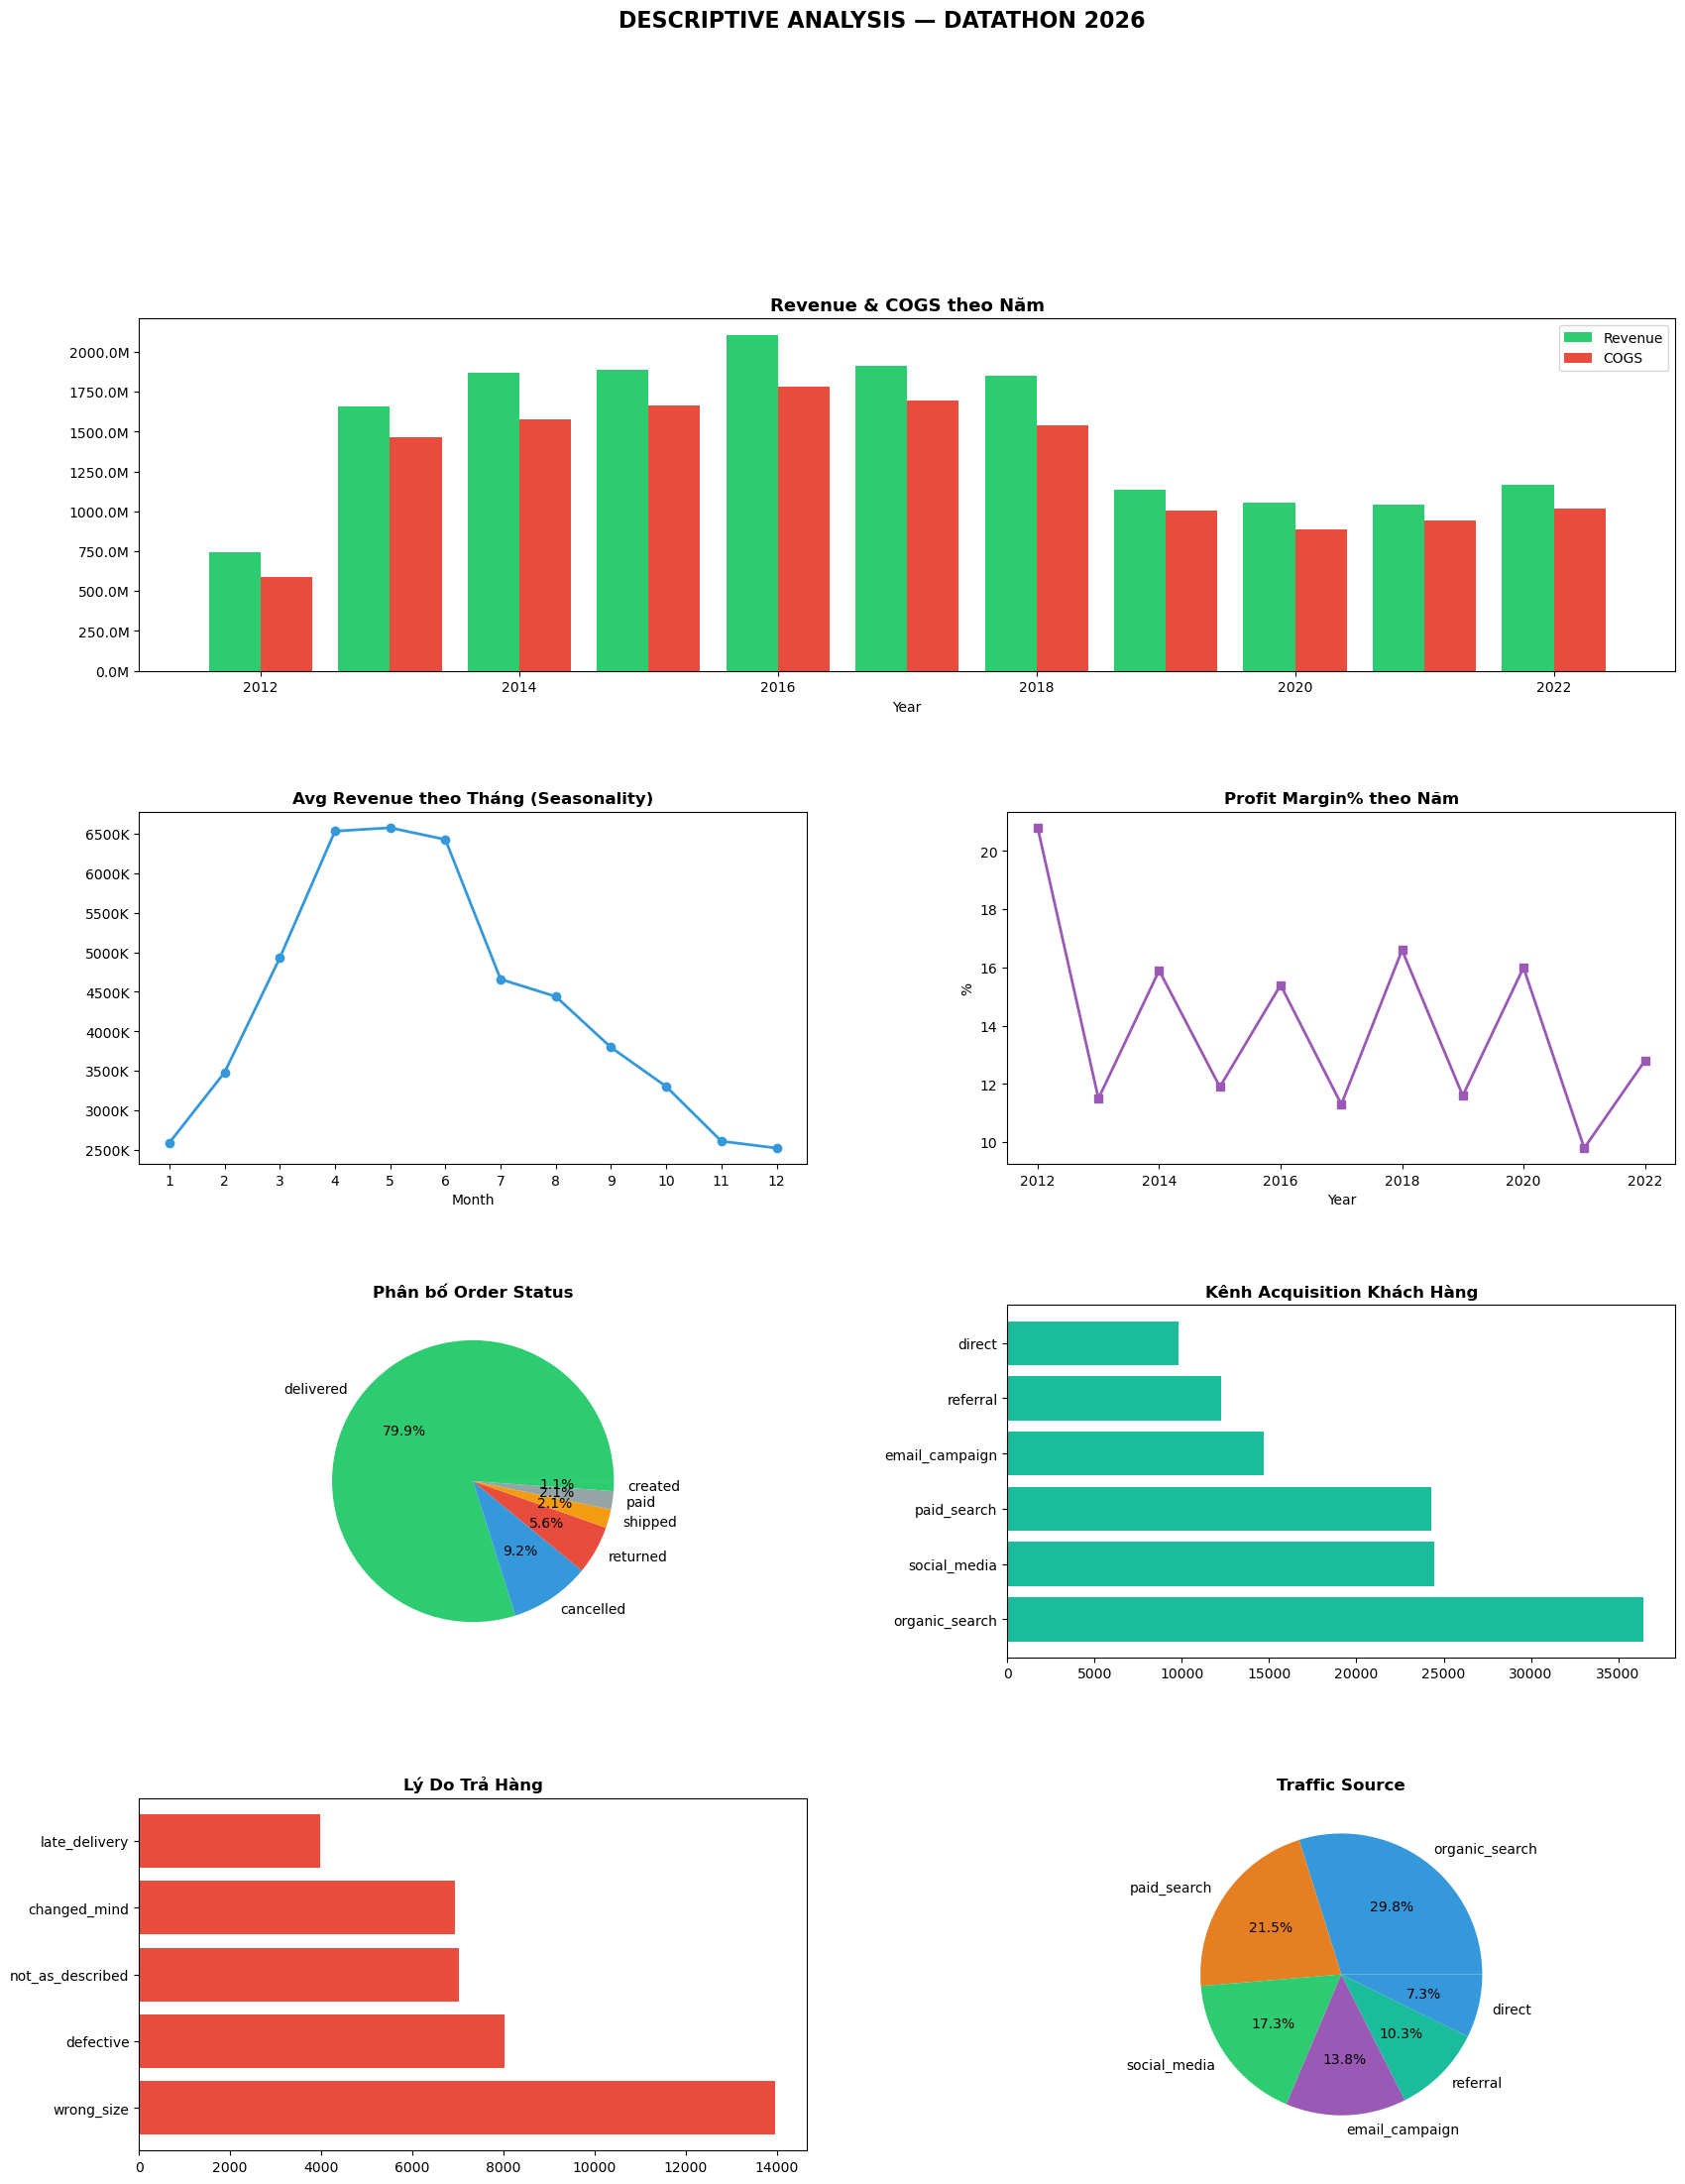


✅ Descriptive Analysis hoàn tất!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. TỔNG QUAN DOANH THU & COGS THEO NĂM
# ============================================================
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['quarter'] = sales['Date'].dt.quarter

yearly = sales.groupby('year')[['Revenue', 'COGS']].sum().reset_index()
yearly['Profit']     = yearly['Revenue'] - yearly['COGS']
yearly['Margin%']    = (yearly['Profit'] / yearly['Revenue'] * 100).round(1)
yearly['Rev_Growth%'] = yearly['Revenue'].pct_change() * 100

print("=" * 60)
print("📊 DOANH THU THEO NĂM")
print("=" * 60)
print(yearly.to_string(index=False))

# ============================================================
# 2. DOANH THU THEO THÁNG (seasonality)
# ============================================================
monthly = sales.groupby('month')[['Revenue', 'COGS']].mean().reset_index()
monthly['Profit'] = monthly['Revenue'] - monthly['COGS']

# ============================================================
# 3. DOANH THU THEO QUÝ
# ============================================================
quarterly = sales.groupby(['year', 'quarter'])[['Revenue', 'COGS']].sum().reset_index()
quarterly['Profit'] = quarterly['Revenue'] - quarterly['COGS']

# ============================================================
# 4. ORDERS — TỔNG QUAN
# ============================================================
print("\n" + "=" * 60)
print("📦 TỔNG QUAN ĐƠN HÀNG")
print("=" * 60)
print(f"Tổng đơn hàng     : {len(orders):,}")
print(f"Tổng khách hàng   : {orders['customer_id'].nunique():,}")

# Order status
print("\n--- Trạng thái đơn hàng ---")
print(orders['order_status'].value_counts(normalize=True).mul(100).round(1).to_string())

# Payment method
print("\n--- Phương thức thanh toán ---")
print(orders['payment_method'].value_counts(normalize=True).mul(100).round(1).to_string())

# Device type
print("\n--- Thiết bị đặt hàng ---")
print(orders['device_type'].value_counts(normalize=True).mul(100).round(1).to_string())

# Order source
print("\n--- Kênh marketing ---")
print(orders['order_source'].value_counts(normalize=True).mul(100).round(1).to_string())

# ============================================================
# 5. CUSTOMERS — TỔNG QUAN
# ============================================================
print("\n" + "=" * 60)
print("👥 TỔNG QUAN KHÁCH HÀNG")
print("=" * 60)
print(f"Tổng khách hàng   : {len(customers):,}")

print("\n--- Giới tính ---")
print(customers['gender'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n--- Nhóm tuổi ---")
print(customers['age_group'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n--- Kênh acquisition ---")
print(customers['acquisition_channel'].value_counts(normalize=True).mul(100).round(1).to_string())

# ============================================================
# 6. PRODUCTS — TỔNG QUAN
# ============================================================
print("\n" + "=" * 60)
print("🛍️  TỔNG QUAN SẢN PHẨM")
print("=" * 60)
print(f"Tổng sản phẩm     : {len(products):,}")

print("\n--- Doanh thu theo Category ---")
cat_rev = (
    order_items
    .merge(products[['product_id', 'category']], on='product_id', how='left')
    .groupby('category')
    .agg(
        total_quantity=('quantity', 'sum'),
        total_revenue=('unit_price', lambda x: (x * order_items.loc[x.index, 'quantity']).sum())
    )
    .sort_values('total_revenue', ascending=False)
)
print(cat_rev.to_string())

# ============================================================
# 7. RETURNS — TỔNG QUAN
# ============================================================
print("\n" + "=" * 60)
print("🔄 TỔNG QUAN TRẢ HÀNG")
print("=" * 60)
print(f"Tổng đơn trả      : {len(returns):,}")
print(f"Return rate       : {len(returns)/len(orders)*100:.1f}%")
print(f"Tổng hoàn tiền    : {returns['refund_amount'].sum():,.0f}")

print("\n--- Lý do trả hàng ---")
print(returns['return_reason'].value_counts(normalize=True).mul(100).round(1).to_string())

# ============================================================
# 8. WEB TRAFFIC — TỔNG QUAN
# ============================================================
print("\n" + "=" * 60)
print("🌐 TỔNG QUAN WEB TRAFFIC")
print("=" * 60)
print(f"Avg sessions/ngày      : {web_traffic['sessions'].mean():,.0f}")
print(f"Avg unique visitors    : {web_traffic['unique_visitors'].mean():,.0f}")
print(f"Avg bounce rate        : {web_traffic['bounce_rate'].mean():.1%}")
print(f"Avg session duration   : {web_traffic['avg_session_duration_sec'].mean():.0f}s")

print("\n--- Traffic source ---")
print(web_traffic['traffic_source'].value_counts(normalize=True).mul(100).round(1).to_string())

# ============================================================
# 9. VISUALIZATIONS
# ============================================================
fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# Plot 1 — Revenue & COGS theo năm
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(yearly['year'] - 0.2, yearly['Revenue'], width=0.4, label='Revenue', color='#2ecc71')
ax1.bar(yearly['year'] + 0.2, yearly['COGS'],    width=0.4, label='COGS',    color='#e74c3c')
ax1.set_title('Revenue & COGS theo Năm', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year'); ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 2 — Revenue theo tháng (seasonality)
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(monthly['month'], monthly['Revenue'], marker='o', color='#3498db', linewidth=2)
ax2.set_title('Avg Revenue theo Tháng (Seasonality)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month'); ax2.set_xticks(range(1, 13))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Plot 3 — Profit Margin theo năm
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(yearly['year'], yearly['Margin%'], marker='s', color='#9b59b6', linewidth=2)
ax3.set_title('Profit Margin% theo Năm', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year'); ax3.set_ylabel('%')

# Plot 4 — Order status
ax4 = fig.add_subplot(gs[2, 0])
status_counts = orders['order_status'].value_counts()
ax4.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71','#3498db','#e74c3c','#f39c12','#95a5a6'])
ax4.set_title('Phân bố Order Status', fontsize=12, fontweight='bold')

# Plot 5 — Acquisition channel
ax5 = fig.add_subplot(gs[2, 1])
acq = customers['acquisition_channel'].value_counts()
ax5.barh(acq.index, acq.values, color='#1abc9c')
ax5.set_title('Kênh Acquisition Khách Hàng', fontsize=12, fontweight='bold')

# Plot 6 — Return reason
ax6 = fig.add_subplot(gs[3, 0])
ret = returns['return_reason'].value_counts()
ax6.barh(ret.index, ret.values, color='#e74c3c')
ax6.set_title('Lý Do Trả Hàng', fontsize=12, fontweight='bold')

# Plot 7 — Web traffic theo nguồn
ax7 = fig.add_subplot(gs[3, 1])
src = web_traffic['traffic_source'].value_counts()
ax7.pie(src, labels=src.index, autopct='%1.1f%%',
        colors=['#3498db','#e67e22','#2ecc71','#9b59b6','#1abc9c'])
ax7.set_title('Traffic Source', fontsize=12, fontweight='bold')

plt.suptitle('DESCRIPTIVE ANALYSIS — DATATHON 2026', 
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('descriptive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Descriptive Analysis hoàn tất!")

Text(0.5, 0.98, 'MASTER TABLE — Customers & Products')

([<matplotlib.patches.Wedge at 0x131f1e810>,
 [Text(0.03754594860754498, 1.0993590413250622, 'Female'),
  Text(-0.17379916780509816, -1.0861831564106743, 'Male'),
  Text(1.0914824897369064, -0.13662347747632547, 'Non-binary')],
 [Text(0.02047960833138817, 0.5996503861773066, '48.9%'),
  Text(-0.09479954607550807, -0.5924635398603678, '47.1%'),
  Text(0.5953540853110398, -0.07452189680526844, '4.0%')])

Text(0.5, 1.0, 'Giới tính khách hàng')

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Nhóm tuổi')

...

<BarContainer object of 8 artists>

Text(0.5, 1.0, 'Sản phẩm theo Segment')

Text(0.5, 1.0, 'Price vs COGS')

Text(0.5, 0, 'COGS')

Text(0, 0.5, 'Price')

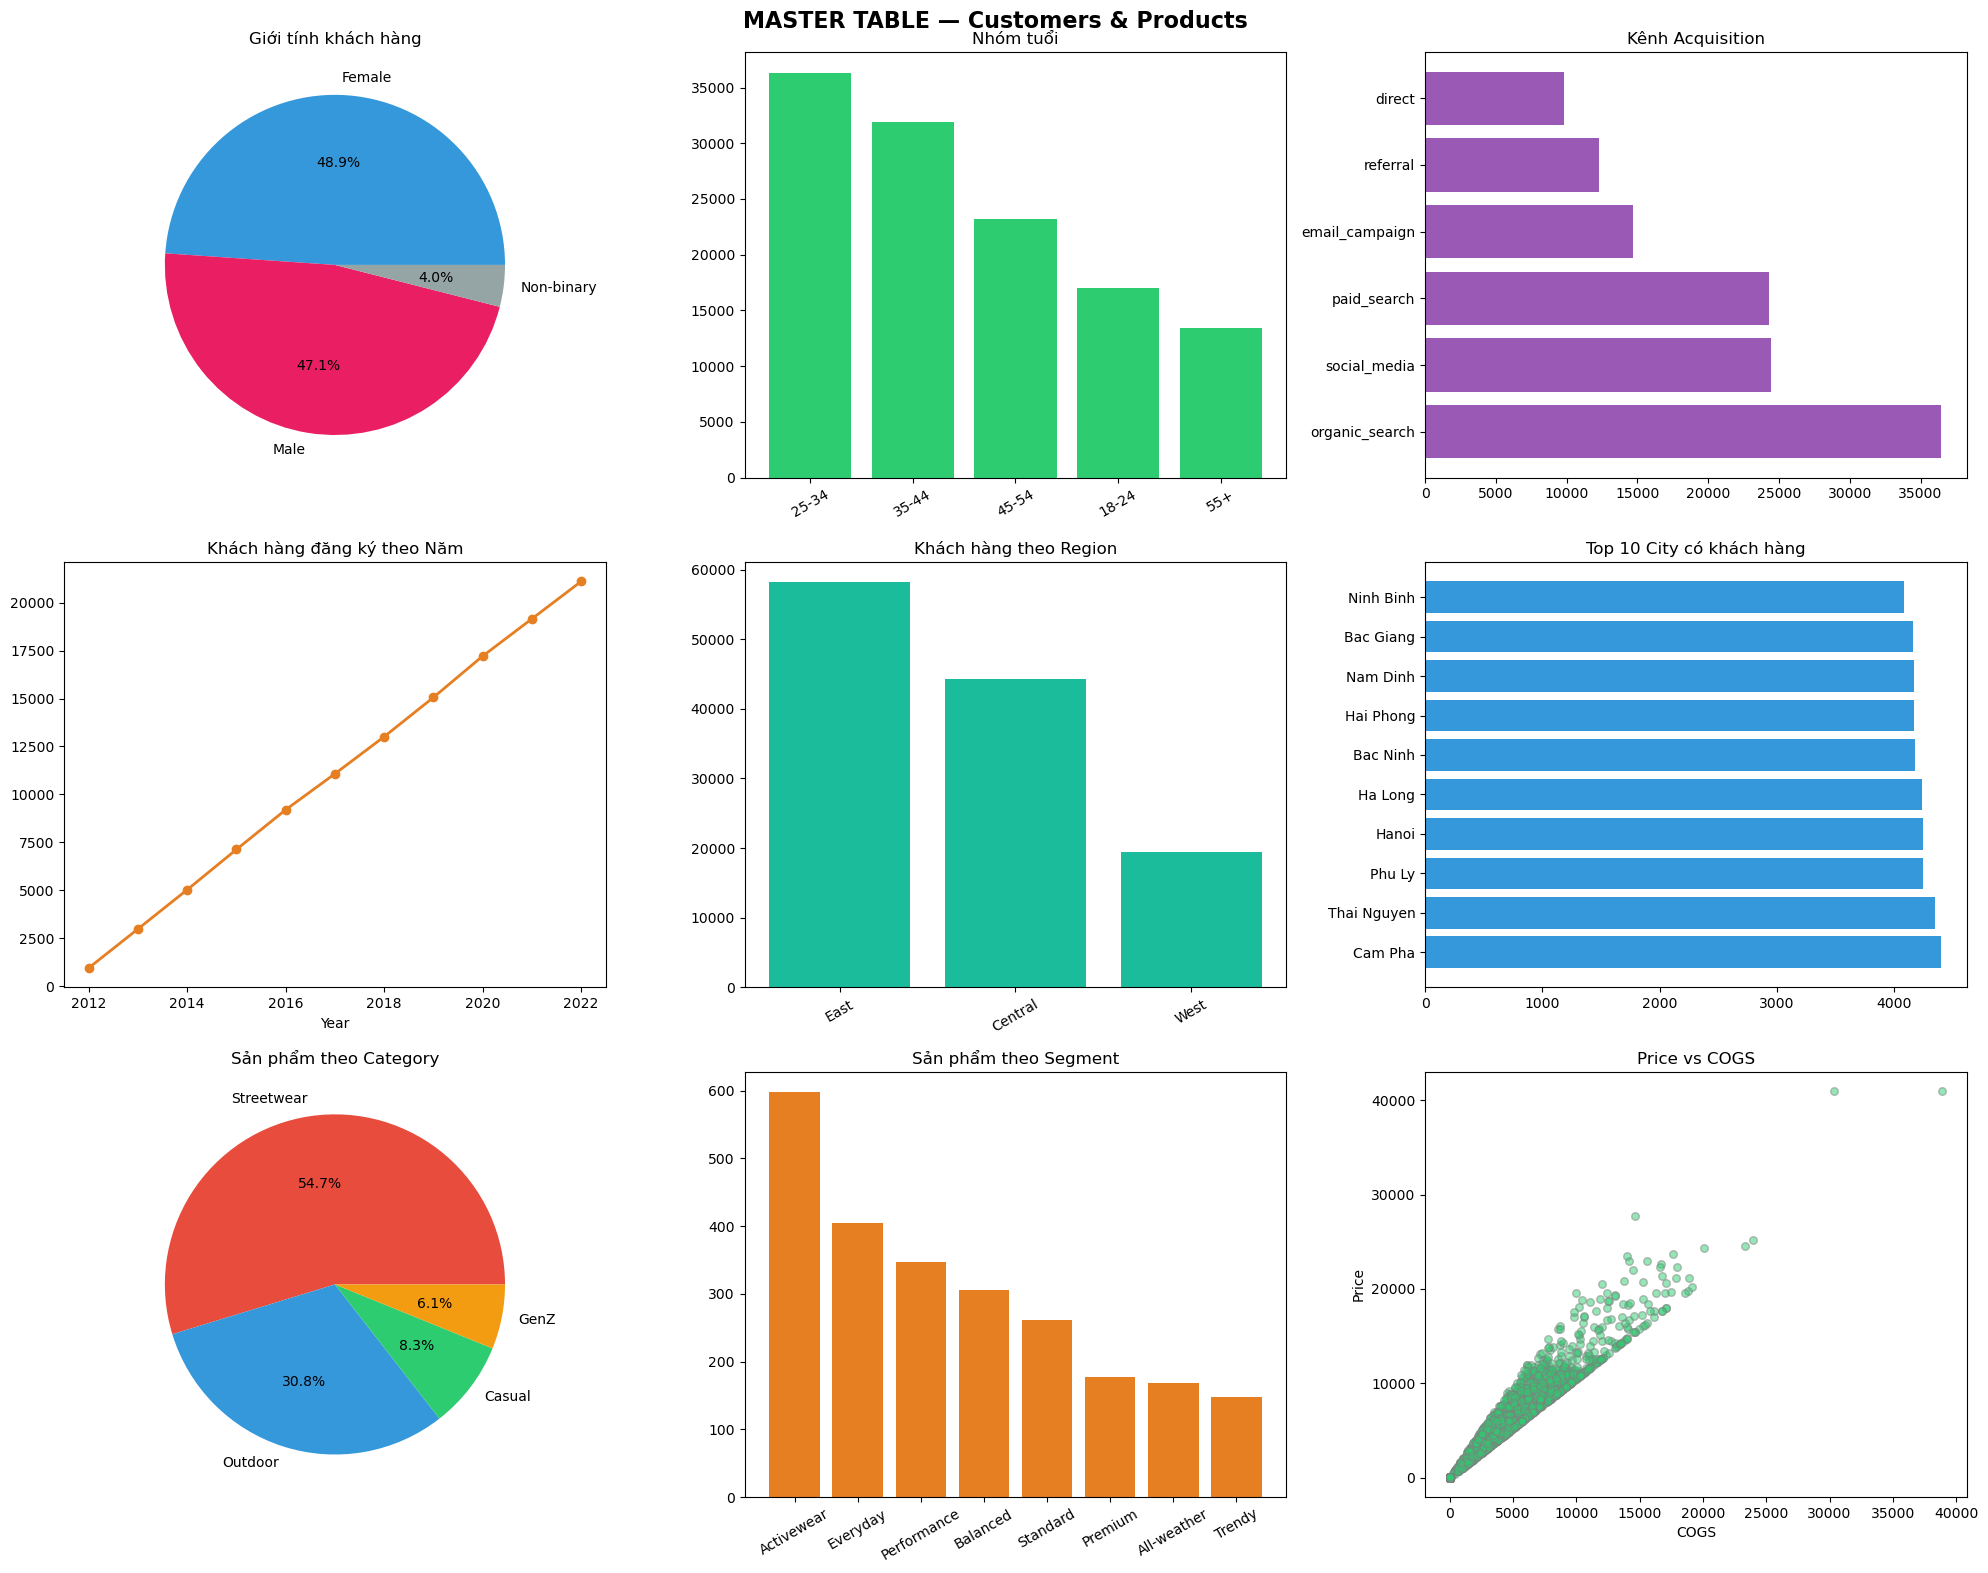

✅ Master Table charts done!


Text(0.5, 0.98, 'TRANSACTION TABLE — Orders, Payments, Returns')

<BarContainer object of 11 artists>

Text(0.5, 1.0, 'Số đơn hàng theo Năm')

Text(0.5, 0, 'Year')

...

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Lý do trả hàng')

(array([1.6154e+04, 9.1080e+03, 4.4240e+03, 3.2520e+03, 1.9720e+03,
        1.4530e+03, 9.7100e+02, 7.4800e+02, 5.1100e+02, 3.8200e+02,
        2.8000e+02, 2.2300e+02, 1.4300e+02, 1.0600e+02, 7.0000e+01,
        5.0000e+01, 3.6000e+01, 2.0000e+01, 6.0000e+00, 9.0000e+00,
        4.0000e+00, 7.0000e+00, 3.0000e+00, 3.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([   458.81      ,   5808.11433333,  11157.41866667,  16506.723     ,
         21856.02733333,  27205.33166667,  32554.636     ,  37903.94033333,
         43253.24466667,  48602.549     ,  53951.85333333,  59301.15766667,
         64650.462     ,  69999.76633333,  75349.07066667,  80698.375     ,
         86047.67933333,  91396.98366667,  96746.288     , 102095.59233333,
        107444.89666667, 112794.201     , 118143.50533333, 123492.80966667,
        128842.114     , 134191.41833333, 139540.72266667, 144890.027     ,
        150239.33133333, 155588.63566667, 160937.94      ]

Text(0.5, 1.0, 'Phân phối Refund Amount')

Text(0.5, 0, 'Refund Amount')

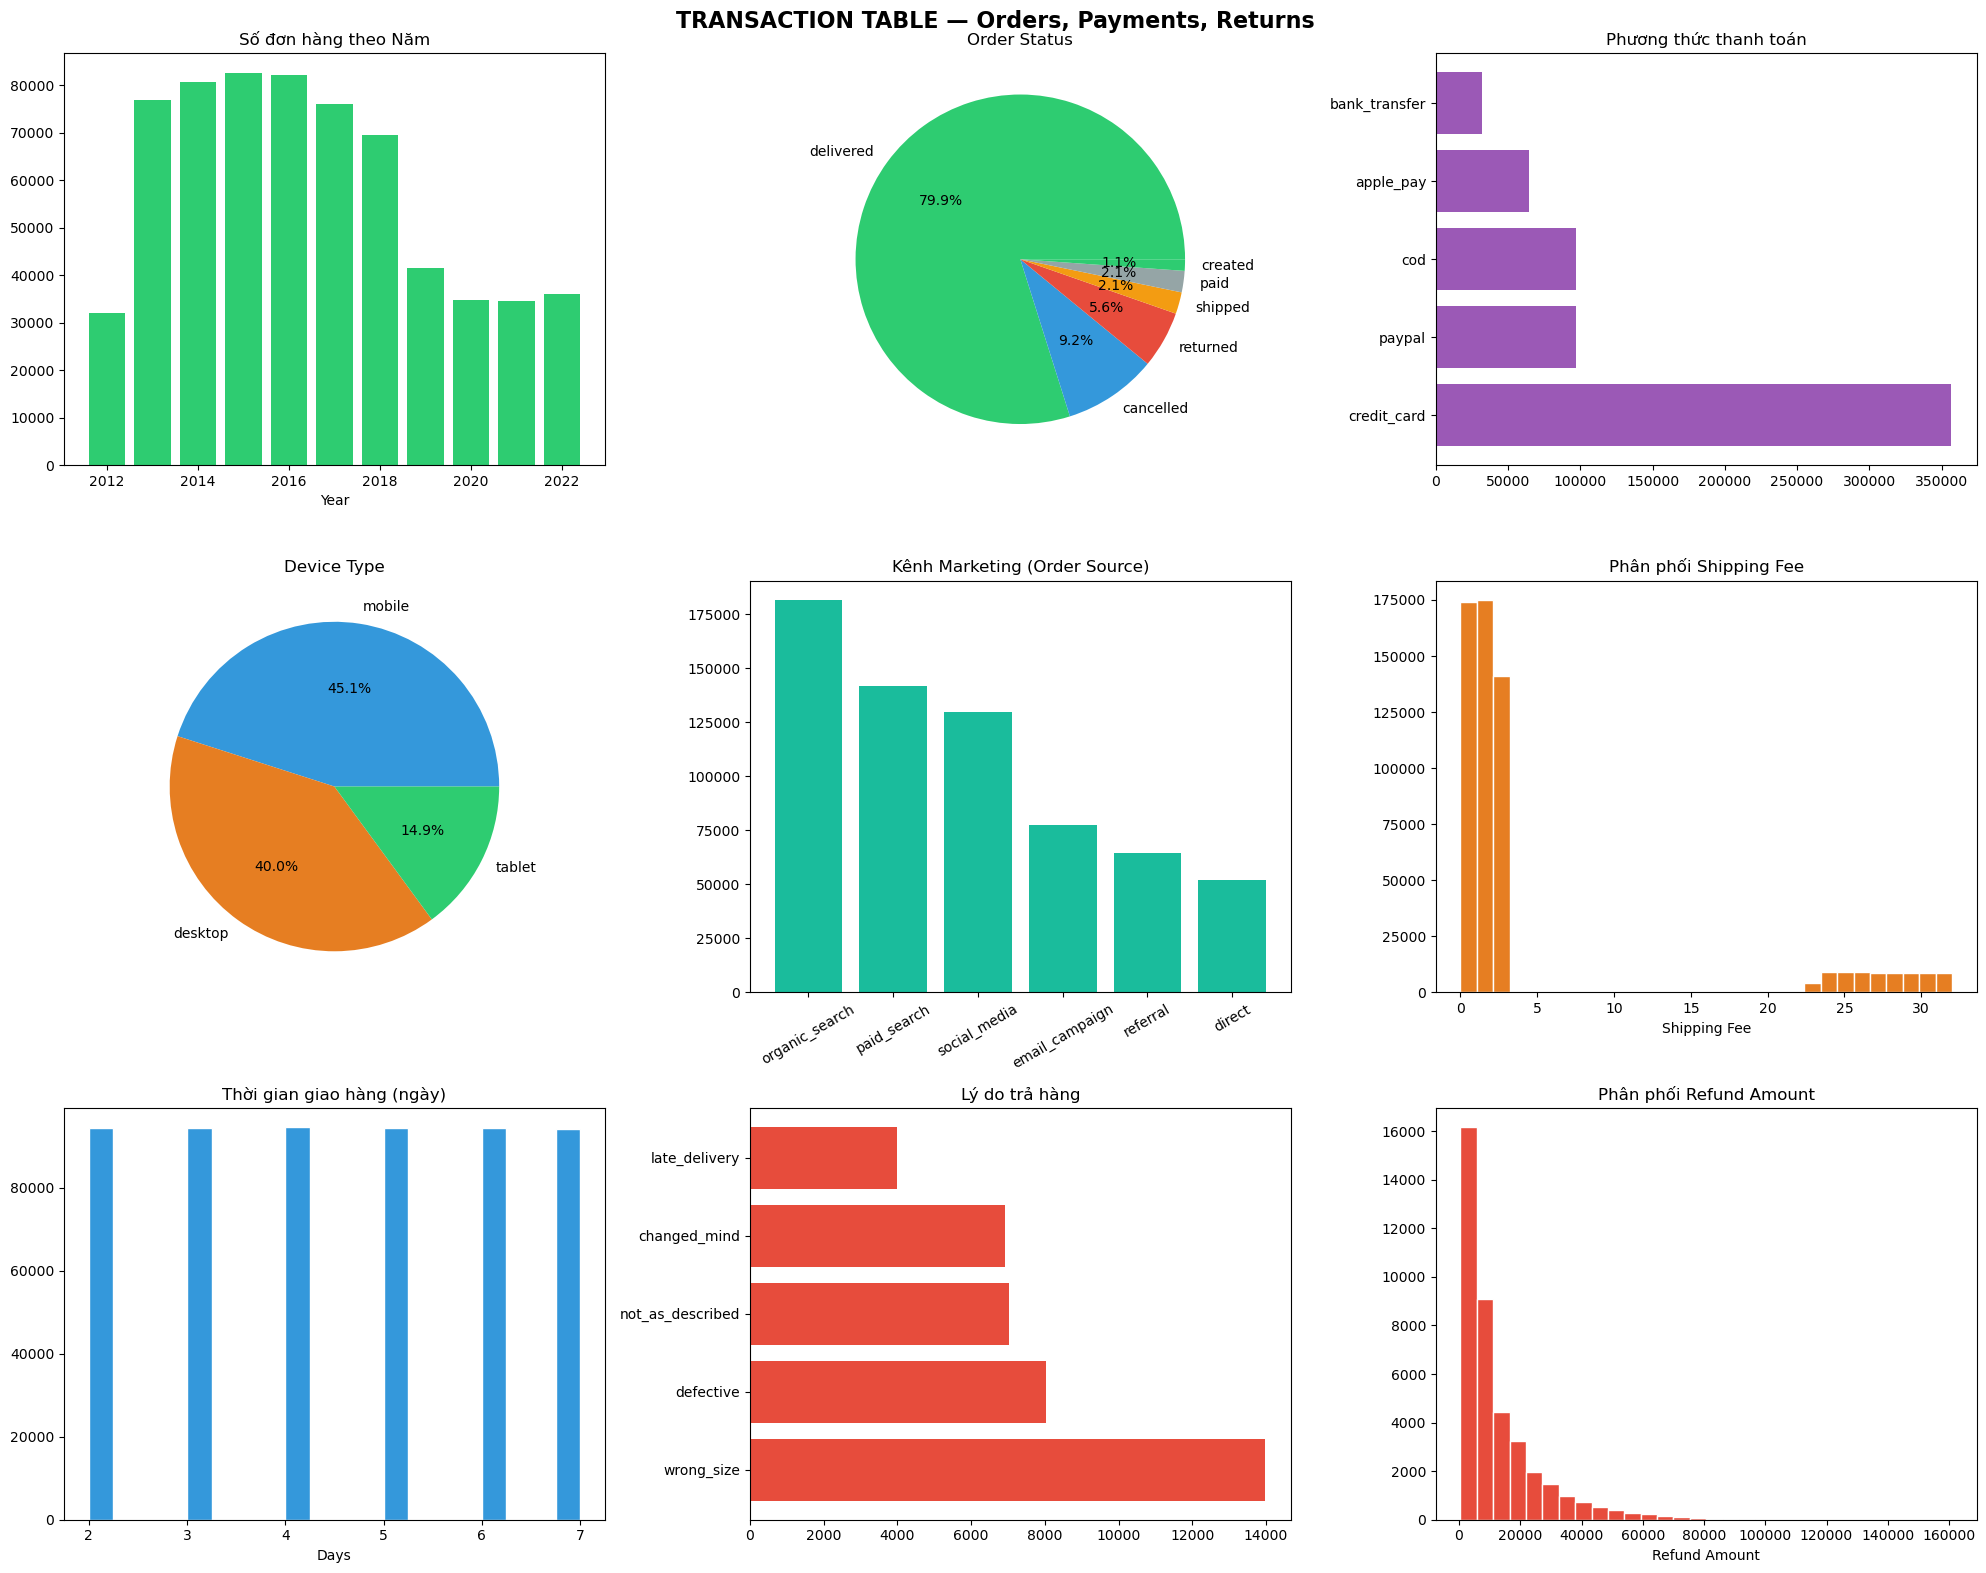

✅ Transaction Table charts done!


Text(0.5, 0.98, 'OPERATIONAL TABLE — Inventory & Web Traffic')

Text(0.5, 1.0, 'Avg Stock on Hand theo Năm')

Text(0.5, 0, 'Year')

<BarContainer object of 4 artists>

...

Text(0.5, 1.0, 'Avg Bounce Rate% theo Source')

Text(0.5, 0, '%')

<BarContainer object of 6 artists>

Text(0.5, 1.0, 'Avg Session Duration (sec) theo Source')

Text(0.5, 0, 'Seconds')

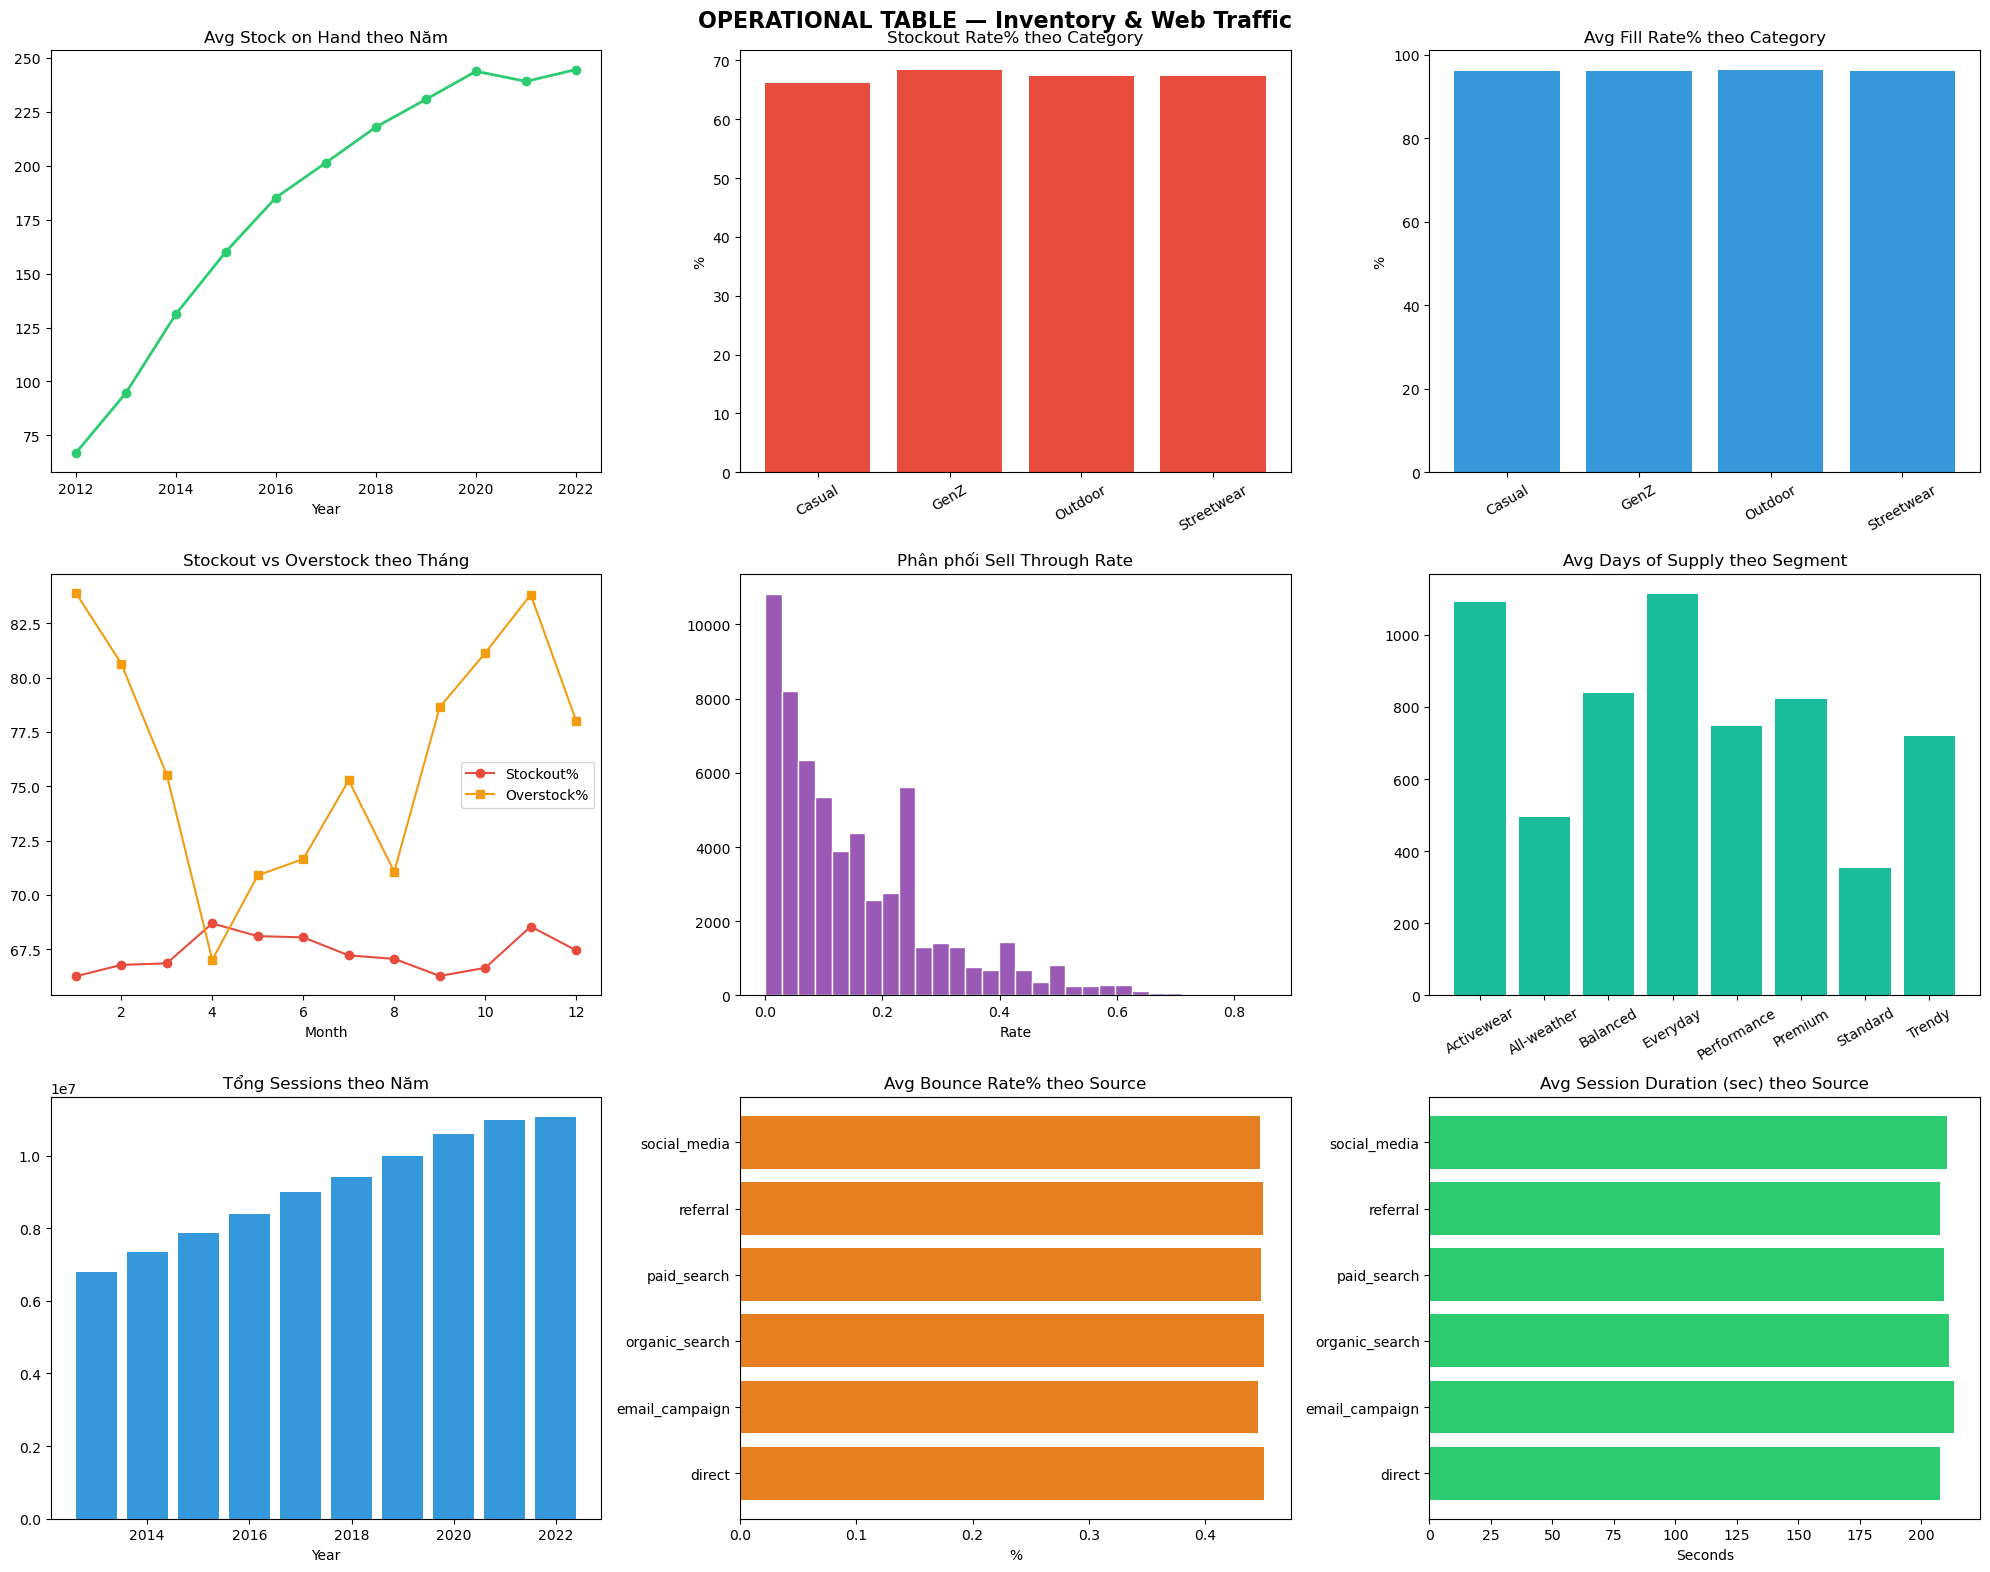

✅ Operational Table charts done!


Text(0.5, 0.98, 'ANALYTIC TABLE — Sales, Reviews & Promotions')

<BarContainer object of 11 artists>

Text(0.5, 1.0, 'Tổng Revenue theo Năm')

Text(0.5, 1.0, 'Revenue vs COGS theo Năm')

...

(1.0, 5.0)

<BarContainer object of 10 artists>

Text(0.5, 1.0, 'Số Promotion theo Năm')

([<matplotlib.patches.Wedge at 0x143945af0>,
 [Text(-1.0461621424642782, 0.33991877217145816, 'percentage'),
  Text(1.0461621185951564, -0.33991884563303376, 'fixed')],
 [Text(-0.5706338958896062, 0.18541023936624987, '90.0%'),
  Text(0.5706338828700852, -0.1854102794362002, '10.0%')])

Text(0.5, 1.0, 'Loại Promotion')

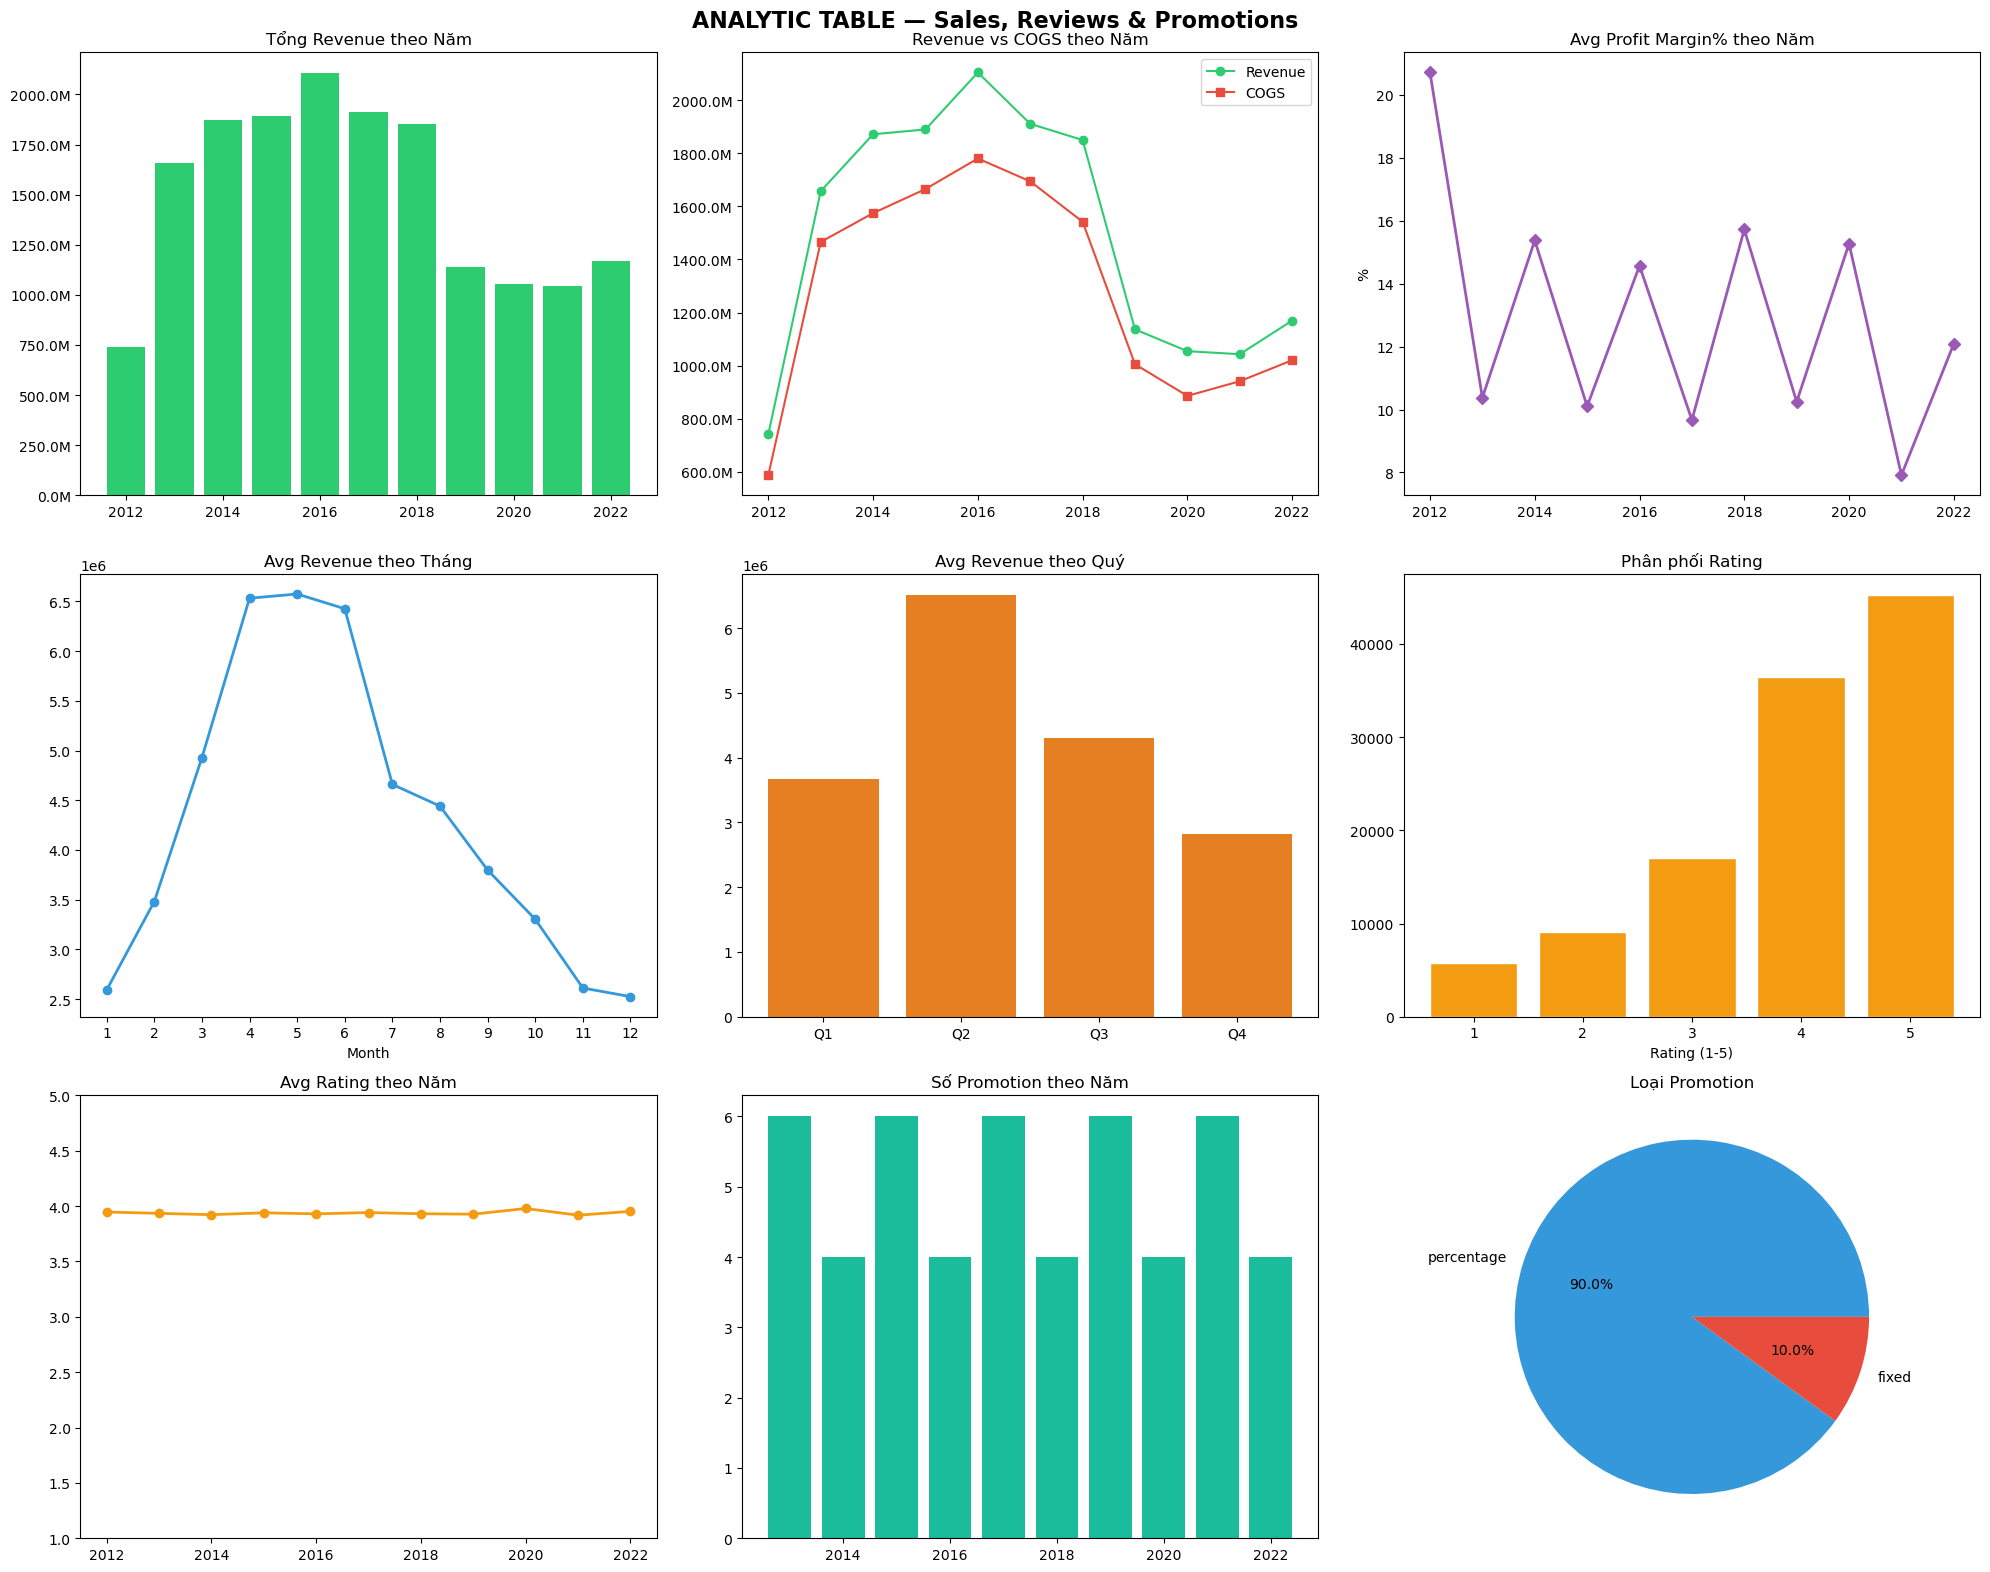

✅ Analytic Table charts done!

🎉 Toàn bộ Descriptive Analysis hoàn tất!


In [14]:
# ============================================================
# DESCRIPTIVE ANALYSIS — THEO TỪNG BẢNG
# ============================================================

# ============================================================
# BẢNG 1 — MASTER: CUSTOMERS + GEOGRAPHY + PRODUCTS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('MASTER TABLE — Customers & Products', fontsize=16, fontweight='bold')

# 1.1 Giới tính
gender = customers['gender'].value_counts()
axes[0,0].pie(gender, labels=gender.index, autopct='%1.1f%%',
              colors=['#3498db','#e91e63','#95a5a6'])
axes[0,0].set_title('Giới tính khách hàng')

# 1.2 Nhóm tuổi
age = customers['age_group'].value_counts()
axes[0,1].bar(age.index, age.values, color='#2ecc71')
axes[0,1].set_title('Nhóm tuổi')
axes[0,1].tick_params(axis='x', rotation=30)

# 1.3 Kênh acquisition
acq = customers['acquisition_channel'].value_counts()
axes[0,2].barh(acq.index, acq.values, color='#9b59b6')
axes[0,2].set_title('Kênh Acquisition')

# 1.4 Khách hàng đăng ký theo năm
customers['signup_year'] = pd.to_datetime(customers['signup_date']).dt.year
signup_yr = customers['signup_year'].value_counts().sort_index()
axes[1,0].plot(signup_yr.index, signup_yr.values, marker='o', color='#e67e22', linewidth=2)
axes[1,0].set_title('Khách hàng đăng ký theo Năm')
axes[1,0].set_xlabel('Year')

# 1.5 Khách hàng theo Region
region_count = geography.merge(
    customers[['zip']], on='zip', how='inner'
)['region'].value_counts()
axes[1,1].bar(region_count.index, region_count.values, color='#1abc9c')
axes[1,1].set_title('Khách hàng theo Region')
axes[1,1].tick_params(axis='x', rotation=30)

# 1.6 Top 10 City
city_count = geography.merge(
    customers[['zip']], on='zip', how='inner'
)['city'].value_counts().head(10)
axes[1,2].barh(city_count.index, city_count.values, color='#3498db')
axes[1,2].set_title('Top 10 City có khách hàng')

# 1.7 Sản phẩm theo Category
cat = products['category'].value_counts()
axes[2,0].pie(cat, labels=cat.index, autopct='%1.1f%%',
              colors=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
axes[2,0].set_title('Sản phẩm theo Category')

# 1.8 Sản phẩm theo Segment
seg = products['segment'].value_counts()
axes[2,1].bar(seg.index, seg.values, color='#e67e22')
axes[2,1].set_title('Sản phẩm theo Segment')
axes[2,1].tick_params(axis='x', rotation=30)

# 1.9 Price vs COGS distribution
axes[2,2].scatter(products['cogs'], products['price'],
                  alpha=0.5, color='#2ecc71', edgecolors='gray', s=30)
axes[2,2].set_title('Price vs COGS')
axes[2,2].set_xlabel('COGS'); axes[2,2].set_ylabel('Price')

plt.tight_layout()
plt.savefig('descriptive_master.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Master Table charts done!")

# ============================================================
# BẢNG 2 — TRANSACTION: ORDERS + ORDER_ITEMS + PAYMENTS + SHIPMENTS + RETURNS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('TRANSACTION TABLE — Orders, Payments, Returns', fontsize=16, fontweight='bold')

orders['order_year']  = orders['order_date'].dt.year
orders['order_month'] = orders['order_date'].dt.month

# 2.1 Orders theo năm
ord_yr = orders.groupby('order_year').size()
axes[0,0].bar(ord_yr.index, ord_yr.values, color='#2ecc71')
axes[0,0].set_title('Số đơn hàng theo Năm')
axes[0,0].set_xlabel('Year')

# 2.2 Order status
status = orders['order_status'].value_counts()
axes[0,1].pie(status, labels=status.index, autopct='%1.1f%%',
              colors=['#2ecc71','#3498db','#e74c3c','#f39c12','#95a5a6'])
axes[0,1].set_title('Order Status')

# 2.3 Phương thức thanh toán
pay = orders['payment_method'].value_counts()
axes[0,2].barh(pay.index, pay.values, color='#9b59b6')
axes[0,2].set_title('Phương thức thanh toán')

# 2.4 Device type
dev = orders['device_type'].value_counts()
axes[1,0].pie(dev, labels=dev.index, autopct='%1.1f%%',
              colors=['#3498db','#e67e22','#2ecc71'])
axes[1,0].set_title('Device Type')

# 2.5 Order source / kênh marketing
src = orders['order_source'].value_counts()
axes[1,1].bar(src.index, src.values, color='#1abc9c')
axes[1,1].set_title('Kênh Marketing (Order Source)')
axes[1,1].tick_params(axis='x', rotation=30)

# 2.6 Shipping fee distribution
axes[1,2].hist(shipments['shipping_fee'], bins=30, color='#e67e22', edgecolor='white')
axes[1,2].set_title('Phân phối Shipping Fee')
axes[1,2].set_xlabel('Shipping Fee')

# 2.7 Delivery time (ship_date → delivery_date)
shipments['delivery_days'] = (
    shipments['delivery_date'] - shipments['ship_date']
).dt.days
axes[2,0].hist(shipments['delivery_days'].dropna(), bins=20,
               color='#3498db', edgecolor='white')
axes[2,0].set_title('Thời gian giao hàng (ngày)')
axes[2,0].set_xlabel('Days')

# 2.8 Return reason
ret = returns['return_reason'].value_counts()
axes[2,1].barh(ret.index, ret.values, color='#e74c3c')
axes[2,1].set_title('Lý do trả hàng')

# 2.9 Refund amount distribution
axes[2,2].hist(returns['refund_amount'], bins=30, color='#e74c3c', edgecolor='white')
axes[2,2].set_title('Phân phối Refund Amount')
axes[2,2].set_xlabel('Refund Amount')

plt.tight_layout()
plt.savefig('descriptive_transaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Transaction Table charts done!")

# ============================================================
# BẢNG 3 — OPERATIONAL: INVENTORY + WEB TRAFFIC
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('OPERATIONAL TABLE — Inventory & Web Traffic', fontsize=16, fontweight='bold')

inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['inv_year']  = inventory['snapshot_date'].dt.year
inventory['inv_month'] = inventory['snapshot_date'].dt.month

# 3.1 Stock on hand theo năm
inv_yr = inventory.groupby('inv_year')['stock_on_hand'].mean()
axes[0,0].plot(inv_yr.index, inv_yr.values, marker='o', color='#2ecc71', linewidth=2)
axes[0,0].set_title('Avg Stock on Hand theo Năm')
axes[0,0].set_xlabel('Year')

# 3.2 Stockout flag theo category
stockout = inventory.groupby('category')['stockout_flag'].mean() * 100
axes[0,1].bar(stockout.index, stockout.values, color='#e74c3c')
axes[0,1].set_title('Stockout Rate% theo Category')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_ylabel('%')

# 3.3 Fill rate theo category
fill = inventory.groupby('category')['fill_rate'].mean() * 100
axes[0,2].bar(fill.index, fill.values, color='#3498db')
axes[0,2].set_title('Avg Fill Rate% theo Category')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].set_ylabel('%')

# 3.4 Overstock vs Stockout theo tháng
inv_monthly = inventory.groupby('inv_month').agg(
    stockout=('stockout_flag', 'mean'),
    overstock=('overstock_flag', 'mean')
) * 100
axes[1,0].plot(inv_monthly.index, inv_monthly['stockout'],
               marker='o', label='Stockout%', color='#e74c3c')
axes[1,0].plot(inv_monthly.index, inv_monthly['overstock'],
               marker='s', label='Overstock%', color='#f39c12')
axes[1,0].set_title('Stockout vs Overstock theo Tháng')
axes[1,0].set_xlabel('Month'); axes[1,0].legend()

# 3.5 Sell through rate distribution
axes[1,1].hist(inventory['sell_through_rate'].dropna(), bins=30,
               color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Phân phối Sell Through Rate')
axes[1,1].set_xlabel('Rate')

# 3.6 Days of supply theo segment
dos = inventory.groupby('segment')['days_of_supply'].mean()
axes[1,2].bar(dos.index, dos.values, color='#1abc9c')
axes[1,2].set_title('Avg Days of Supply theo Segment')
axes[1,2].tick_params(axis='x', rotation=30)

# 3.7 Web sessions theo năm
web_traffic['wt_year'] = web_traffic['date'].dt.year
wt_yr = web_traffic.groupby('wt_year')['sessions'].sum()
axes[2,0].bar(wt_yr.index, wt_yr.values, color='#3498db')
axes[2,0].set_title('Tổng Sessions theo Năm')
axes[2,0].set_xlabel('Year')

# 3.8 Bounce rate theo traffic source
br = web_traffic.groupby('traffic_source')['bounce_rate'].mean() * 100
axes[2,1].barh(br.index, br.values, color='#e67e22')
axes[2,1].set_title('Avg Bounce Rate% theo Source')
axes[2,1].set_xlabel('%')

# 3.9 Avg session duration theo nguồn
dur = web_traffic.groupby('traffic_source')['avg_session_duration_sec'].mean()
axes[2,2].barh(dur.index, dur.values, color='#2ecc71')
axes[2,2].set_title('Avg Session Duration (sec) theo Source')
axes[2,2].set_xlabel('Seconds')

plt.tight_layout()
plt.savefig('descriptive_operational.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Operational Table charts done!")

# ============================================================
# BẢNG 4 — ANALYTIC: SALES + REVIEWS + PROMOTIONS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('ANALYTIC TABLE — Sales, Reviews & Promotions', fontsize=16, fontweight='bold')

sales['year']    = sales['Date'].dt.year
sales['month']   = sales['Date'].dt.month
sales['quarter'] = sales['Date'].dt.quarter
sales['Profit']  = sales['Revenue'] - sales['COGS']
sales['Margin%'] = sales['Profit'] / sales['Revenue'] * 100

# 4.1 Revenue theo năm
rev_yr = sales.groupby('year')['Revenue'].sum()
axes[0,0].bar(rev_yr.index, rev_yr.values, color='#2ecc71')
axes[0,0].set_title('Tổng Revenue theo Năm')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

# 4.2 Revenue vs COGS theo năm
cogs_yr = sales.groupby('year')['COGS'].sum()
axes[0,1].plot(rev_yr.index, rev_yr.values,  marker='o', label='Revenue', color='#2ecc71')
axes[0,1].plot(cogs_yr.index, cogs_yr.values, marker='s', label='COGS',   color='#e74c3c')
axes[0,1].set_title('Revenue vs COGS theo Năm')
axes[0,1].legend()
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

# 4.3 Profit margin theo năm
margin_yr = sales.groupby('year')['Margin%'].mean()
axes[0,2].plot(margin_yr.index, margin_yr.values, marker='D', color='#9b59b6', linewidth=2)
axes[0,2].set_title('Avg Profit Margin% theo Năm')
axes[0,2].set_ylabel('%')

# 4.4 Revenue theo tháng (seasonality)
rev_mo = sales.groupby('month')['Revenue'].mean()
axes[1,0].plot(rev_mo.index, rev_mo.values, marker='o', color='#3498db', linewidth=2)
axes[1,0].set_title('Avg Revenue theo Tháng')
axes[1,0].set_xlabel('Month'); axes[1,0].set_xticks(range(1, 13))

# 4.5 Revenue theo quý
rev_q = sales.groupby('quarter')['Revenue'].mean()
axes[1,1].bar(['Q1','Q2','Q3','Q4'], rev_q.values, color='#e67e22')
axes[1,1].set_title('Avg Revenue theo Quý')

# 4.6 Rating distribution
axes[1,2].hist(reviews['rating'], bins=5, range=(0.5, 5.5),
               color='#f39c12', edgecolor='white', rwidth=0.8)
axes[1,2].set_title('Phân phối Rating')
axes[1,2].set_xlabel('Rating (1-5)')
axes[1,2].set_xticks([1,2,3,4,5])

# 4.7 Rating trung bình theo năm
reviews['review_year'] = reviews['review_date'].dt.year
rat_yr = reviews.groupby('review_year')['rating'].mean()
axes[2,0].plot(rat_yr.index, rat_yr.values, marker='o', color='#f39c12', linewidth=2)
axes[2,0].set_title('Avg Rating theo Năm')
axes[2,0].set_ylim(1, 5)

# 4.8 Số lượng promotion theo năm
promotions['promo_year'] = promotions['start_date'].dt.year
promo_yr = promotions.groupby('promo_year').size()
axes[2,1].bar(promo_yr.index, promo_yr.values, color='#1abc9c')
axes[2,1].set_title('Số Promotion theo Năm')

# 4.9 Promotion type
promo_type = promotions['promo_type'].value_counts()
axes[2,2].pie(promo_type, labels=promo_type.index, autopct='%1.1f%%',
              colors=['#3498db','#e74c3c'])
axes[2,2].set_title('Loại Promotion')

plt.tight_layout()
plt.savefig('descriptive_analytic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Analytic Table charts done!")
print("\n🎉 Toàn bộ Descriptive Analysis hoàn tất!")

Text(0.5, 0.98, 'PROMOTIONS TABLE — Descriptive Analysis')

([<matplotlib.patches.Wedge at 0x132806630>,
 [Text(-0.33991877217145866, -1.046162142464278, 'percentage'),
  Text(0.3399188456330338, 1.0461621185951564, 'fixed')],
 [Text(-0.18541023936625015, -0.5706338958896061, '90.0%'),
  Text(0.18541027943620023, 0.5706338828700852, '10.0%')])

Text(0.5, 1.0, 'Loại Promotion\n(% vs Fixed)')

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Kênh Phân Phối Promotion')

...

Text(0.5, 0, 'Số đơn')

([<matplotlib.patches.Wedge at 0x140f2b6e0>,
 [Text(-0.0217883630925135, 1.099784191209234, 'fixed'),
  Text(0.021788470888422794, -1.0997841890736313, 'percentage')],
 [Text(-0.011884561686825543, 0.5998822861141276, '0.6%'),
  Text(0.01188462048459425, -0.5998822849492533, '99.4%')])

Text(0.5, 1.0, 'Tổng Discount Amount\ntheo Loại Promotion')

([<matplotlib.patches.Wedge at 0x140f42ea0>,
 [Text(-0.7530018405458982, -0.8018654676031945, 'Non-stackable'),
  Text(0.7530018780839296, 0.801865432352633, 'Stackable')],
 [Text(-0.41072827666139905, -0.43738116414719697, '76.0%'),
  Text(0.41072829713668885, 0.43738114491961794, '24.0%')])

Text(0.5, 1.0, 'Stackable vs Non-stackable')

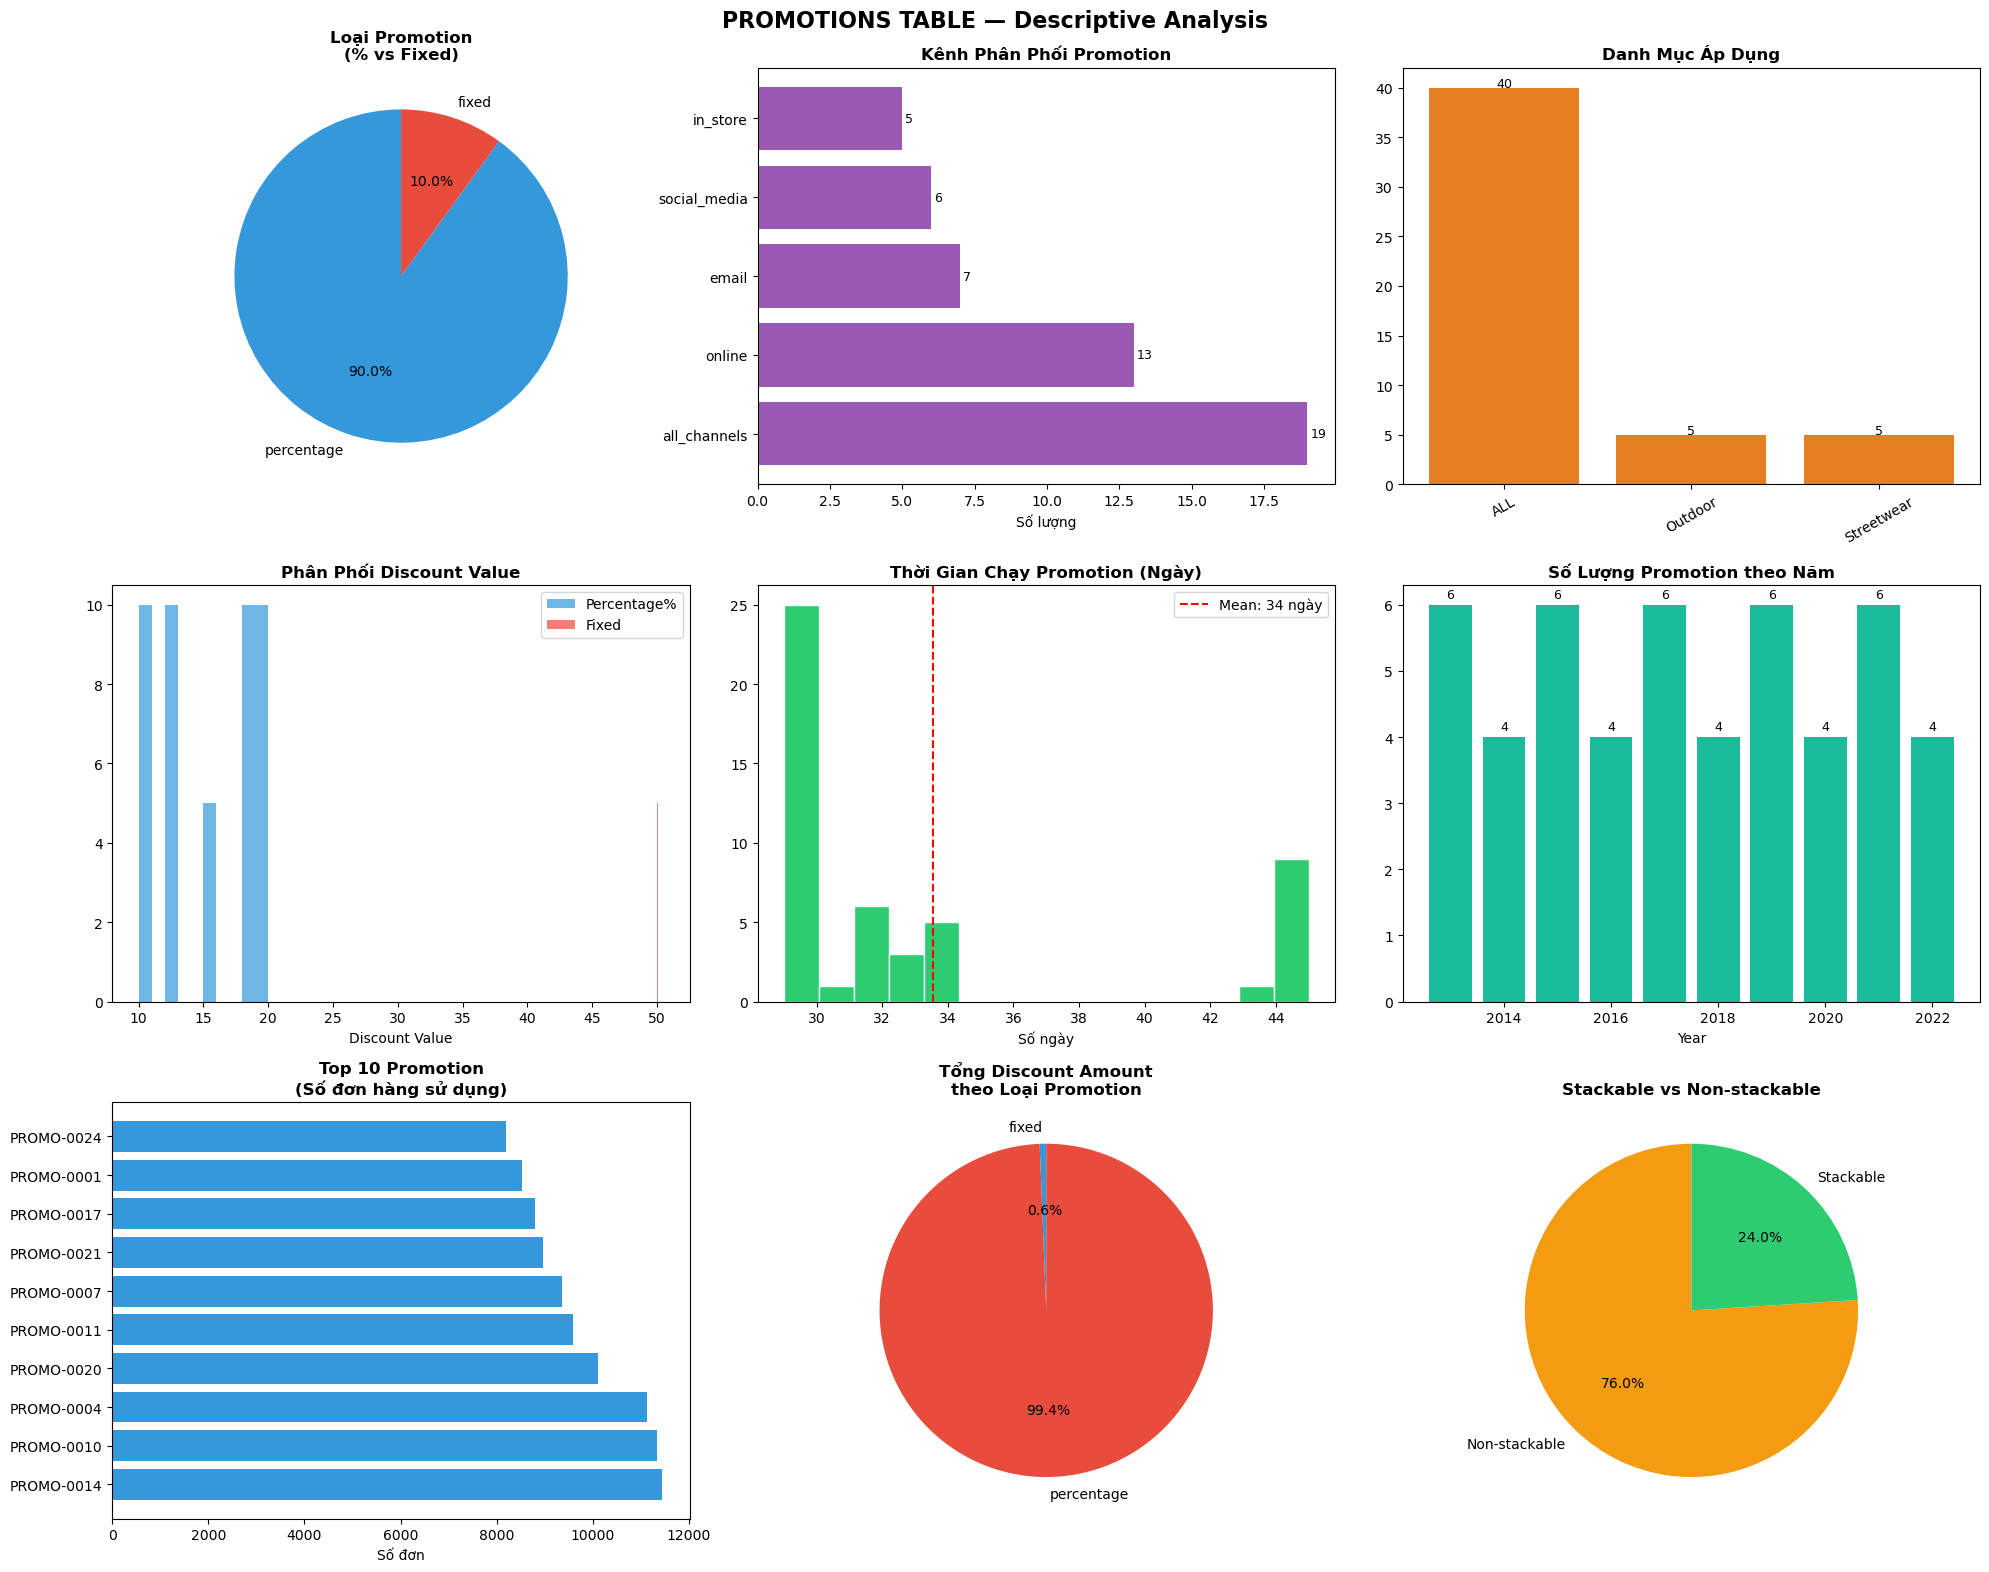

📊 PROMOTIONS — SUMMARY
Tổng số promotion     : 50
Avg duration          : 34 ngày
Max discount (%)      : 20.0%
Avg discount (%)      : 15.0%
Max discount (fixed)  : 50
Avg discount (fixed)  : 50

Tổng đơn dùng promo   : 276,316
Tổng discount amount  : 749,607,320

✅ Promotions charts done!


In [18]:
# ============================================================
# DESCRIPTIVE — PROMOTIONS TABLE
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('PROMOTIONS TABLE — Descriptive Analysis', fontsize=16, fontweight='bold')

# Chuẩn bị data
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date']   = pd.to_datetime(promotions['end_date'])
promotions['duration_days'] = (promotions['end_date'] - promotions['start_date']).dt.days
promotions['promo_year']    = promotions['start_date'].dt.year
promotions['promo_month']   = promotions['start_date'].dt.month

# Join order_items với promotions để tính hiệu quả
promo_usage = (
    order_items[order_items['promo_id'] != 'NO_PROMO']
    .groupby('promo_id')
    .agg(
        total_orders   = ('order_id', 'count'),
        total_discount = ('discount_amount', 'sum'),
        total_revenue  = ('unit_price', 'sum'),
    )
    .reset_index()
    .merge(promotions[['promo_id','promo_name','promo_type',
                        'discount_value','promo_channel',
                        'applicable_category','duration_days',
                        'promo_year']], 
           on='promo_id', how='left')
)

# ============================================================
# 1. Loại promotion (promo_type)
# ============================================================
promo_type = promotions['promo_type'].value_counts()
axes[0,0].pie(promo_type, labels=promo_type.index, autopct='%1.1f%%',
              colors=['#3498db','#e74c3c'], startangle=90)
axes[0,0].set_title('Loại Promotion\n(% vs Fixed)', fontweight='bold')

# ============================================================
# 2. Kênh phân phối (promo_channel)
# ============================================================
channel = promotions['promo_channel'].value_counts()
axes[0,1].barh(channel.index, channel.values, color='#9b59b6')
axes[0,1].set_title('Kênh Phân Phối Promotion', fontweight='bold')
axes[0,1].set_xlabel('Số lượng')
for i, v in enumerate(channel.values):
    axes[0,1].text(v + 0.1, i, str(v), va='center', fontsize=9)

# ============================================================
# 3. Danh mục áp dụng (applicable_category)
# ============================================================
app_cat = promotions['applicable_category'].value_counts()
axes[0,2].bar(app_cat.index, app_cat.values, color='#e67e22')
axes[0,2].set_title('Danh Mục Áp Dụng', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=30)
for i, v in enumerate(app_cat.values):
    axes[0,2].text(i, v + 0.1, str(v), ha='center', fontsize=9)

# ============================================================
# 4. Discount value distribution
# ============================================================
pct_promo  = promotions[promotions['promo_type'] == 'percentage']['discount_value']
fix_promo  = promotions[promotions['promo_type'] == 'fixed']['discount_value']
axes[1,0].hist(pct_promo, bins=10, alpha=0.7, label='Percentage%', color='#3498db')
axes[1,0].hist(fix_promo, bins=10, alpha=0.7, label='Fixed',       color='#e74c3c')
axes[1,0].set_title('Phân Phối Discount Value', fontweight='bold')
axes[1,0].set_xlabel('Discount Value')
axes[1,0].legend()

# ============================================================
# 5. Duration days distribution
# ============================================================
axes[1,1].hist(promotions['duration_days'].dropna(), bins=15,
               color='#2ecc71', edgecolor='white')
axes[1,1].set_title('Thời Gian Chạy Promotion (Ngày)', fontweight='bold')
axes[1,1].set_xlabel('Số ngày')
axes[1,1].axvline(promotions['duration_days'].mean(), 
                   color='red', linestyle='--', 
                   label=f"Mean: {promotions['duration_days'].mean():.0f} ngày")
axes[1,1].legend()

# ============================================================
# 6. Số promotion theo năm
# ============================================================
promo_yr = promotions.groupby('promo_year').size()
axes[1,2].bar(promo_yr.index, promo_yr.values, color='#1abc9c')
axes[1,2].set_title('Số Lượng Promotion theo Năm', fontweight='bold')
axes[1,2].set_xlabel('Year')
for i, (yr, v) in enumerate(zip(promo_yr.index, promo_yr.values)):
    axes[1,2].text(yr, v + 0.1, str(v), ha='center', fontsize=9)

# ============================================================
# 7. Top promotions theo số đơn hàng sử dụng
# ============================================================
top_promo = promo_usage.nlargest(10, 'total_orders')
axes[2,0].barh(top_promo['promo_id'], top_promo['total_orders'], color='#3498db')
axes[2,0].set_title('Top 10 Promotion\n(Số đơn hàng sử dụng)', fontweight='bold')
axes[2,0].set_xlabel('Số đơn')

# ============================================================
# 8. Tổng discount theo promo_type
# ============================================================
disc_by_type = promo_usage.groupby('promo_type')['total_discount'].sum()
axes[2,1].pie(disc_by_type, labels=disc_by_type.index, autopct='%1.1f%%',
              colors=['#3498db','#e74c3c'], startangle=90)
axes[2,1].set_title('Tổng Discount Amount\ntheo Loại Promotion', fontweight='bold')

# ============================================================
# 9. Stackable vs Non-stackable
# ============================================================
stack = promotions['stackable_flag'].value_counts()
stack.index = ['Non-stackable' if x == 0 else 'Stackable' for x in stack.index]
axes[2,2].pie(stack, labels=stack.index, autopct='%1.1f%%',
              colors=['#f39c12','#2ecc71'], startangle=90)
axes[2,2].set_title('Stackable vs Non-stackable', fontweight='bold')

plt.tight_layout()
plt.savefig('descriptive_promotions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY STATS
# ============================================================
print("=" * 50)
print("📊 PROMOTIONS — SUMMARY")
print("=" * 50)
print(f"Tổng số promotion     : {len(promotions)}")
print(f"Avg duration          : {promotions['duration_days'].mean():.0f} ngày")
print(f"Max discount (%)      : {pct_promo.max():.1f}%")
print(f"Avg discount (%)      : {pct_promo.mean():.1f}%")
print(f"Max discount (fixed)  : {fix_promo.max():,.0f}")
print(f"Avg discount (fixed)  : {fix_promo.mean():,.0f}")
print(f"\nTổng đơn dùng promo   : {promo_usage['total_orders'].sum():,}")
print(f"Tổng discount amount  : {promo_usage['total_discount'].sum():,.0f}")
print(f"\n✅ Promotions charts done!")

Text(0.5, 0.98, 'PAYMENTS TABLE — Descriptive Analysis')

(array([1.46321e+05, 1.29237e+05, 8.42770e+04, 7.01980e+04, 5.37230e+04,
        3.96220e+04, 3.12430e+04, 2.20700e+04, 1.73500e+04, 1.37020e+04,
        9.54500e+03, 9.59100e+03, 5.38700e+03, 6.44100e+03, 2.34700e+03,
        2.30400e+03, 8.58000e+02, 6.76000e+02, 5.32000e+02, 3.48000e+02,
        3.20000e+02, 2.35000e+02, 1.37000e+02, 1.71000e+02, 1.34000e+02,
        6.20000e+01, 3.20000e+01, 3.70000e+01, 2.40000e+01, 4.00000e+00,
        7.00000e+00, 1.00000e+00, 2.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 2.00000e+00, 0.00000e+00, 0.00000e+00,
        2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([   389.74  ,   7013.3532,  13636.9664,  20260.5796,  26884.1928,
         33507.806 ,  40131.4192,  46755.0324,  53378.6456,  60002.2588,
         66625.872 ,  73249.4852,  79873.0984,  86496.7116,  93120.3248,
         99743.938 , 106367.5512, 112991.1644, 11

Text(0.5, 1.0, 'Phân Phối Payment Value')

Text(0.5, 0, 'Payment Value')

Text(0, 0.5, 'Frequency')

...

Text(1.05, 4, '1.0')

{'whiskers': [<matplotlib.lines.Line2D at 0x14106b110>,
 'caps': [<matplotlib.lines.Line2D at 0x140f48bf0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x13624e5d0>,
 'medians': [<matplotlib.lines.Line2D at 0x140f4a750>,
 'fliers': [<matplotlib.lines.Line2D at 0x140f4b950>,
 'means': []}

Text(0.5, 1.0, 'Payment Value theo Số Kỳ Trả Góp')

Text(0.5, 0, 'Installments')

Text(0, 0.5, 'Payment Value')

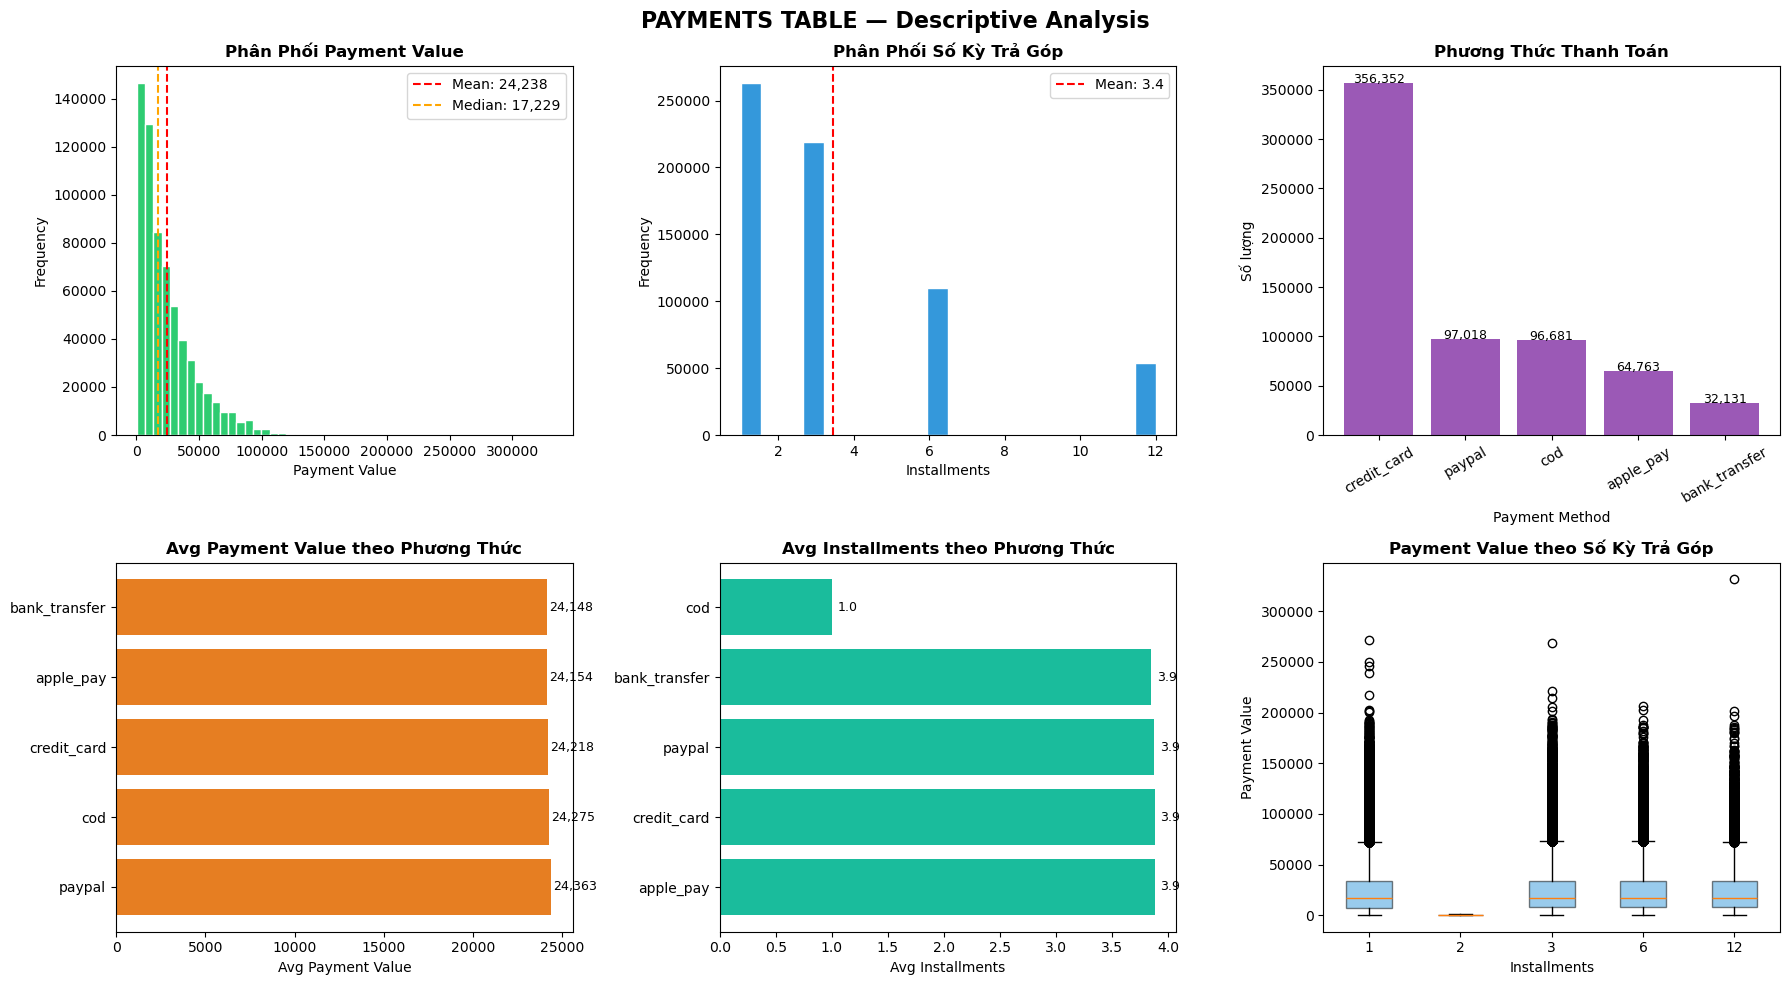

💳 PAYMENTS — SUMMARY STATS
Tổng giao dịch        : 646,945
Avg payment value     : 24,238
Median payment value  : 17,229
Max payment value     : 331,570
Min payment value     : 390
Avg installments      : 3.4

Theo phương thức:
                   mean   median   count
payment_method                          
apple_pay       24154.0  17207.0   64763
bank_transfer   24148.0  17104.0   32131
cod             24275.0  17197.0   96681
credit_card     24218.0  17222.0  356352
paypal          24363.0  17332.0   97018


In [19]:
# ============================================================
# DESCRIPTIVE — PAYMENTS TABLE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('PAYMENTS TABLE — Descriptive Analysis', fontsize=16, fontweight='bold')

# 1. Payment value distribution
axes[0,0].hist(payments['payment_value'], bins=50, 
               color='#2ecc71', edgecolor='white')
axes[0,0].set_title('Phân Phối Payment Value', fontweight='bold')
axes[0,0].set_xlabel('Payment Value')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(payments['payment_value'].mean(), 
                   color='red', linestyle='--',
                   label=f"Mean: {payments['payment_value'].mean():,.0f}")
axes[0,0].axvline(payments['payment_value'].median(), 
                   color='orange', linestyle='--',
                   label=f"Median: {payments['payment_value'].median():,.0f}")
axes[0,0].legend()

# 2. Installments distribution
axes[0,1].hist(payments['installments'], bins=20,
               color='#3498db', edgecolor='white')
axes[0,1].set_title('Phân Phối Số Kỳ Trả Góp', fontweight='bold')
axes[0,1].set_xlabel('Installments')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(payments['installments'].mean(),
                   color='red', linestyle='--',
                   label=f"Mean: {payments['installments'].mean():.1f}")
axes[0,1].legend()

# 3. Payment method
pay_method = payments['payment_method'].value_counts()
axes[0,2].bar(pay_method.index, pay_method.values, color='#9b59b6')
axes[0,2].set_title('Phương Thức Thanh Toán', fontweight='bold')
axes[0,2].set_xlabel('Payment Method')
axes[0,2].set_ylabel('Số lượng')
axes[0,2].tick_params(axis='x', rotation=30)
for i, v in enumerate(pay_method.values):
    axes[0,2].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# 4. Avg payment value theo payment method
avg_pay = payments.groupby('payment_method')['payment_value'].mean().sort_values(ascending=False)
axes[1,0].barh(avg_pay.index, avg_pay.values, color='#e67e22')
axes[1,0].set_title('Avg Payment Value theo Phương Thức', fontweight='bold')
axes[1,0].set_xlabel('Avg Payment Value')
for i, v in enumerate(avg_pay.values):
    axes[1,0].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

# 5. Avg installments theo payment method
avg_inst = payments.groupby('payment_method')['installments'].mean().sort_values(ascending=False)
axes[1,1].barh(avg_inst.index, avg_inst.values, color='#1abc9c')
axes[1,1].set_title('Avg Installments theo Phương Thức', fontweight='bold')
axes[1,1].set_xlabel('Avg Installments')
for i, v in enumerate(avg_inst.values):
    axes[1,1].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

# 6. Payment value theo installments (boxplot)
install_groups = [
    payments[payments['installments'] == i]['payment_value']
    for i in sorted(payments['installments'].unique())
]
axes[1,2].boxplot(install_groups, 
                   labels=sorted(payments['installments'].unique()),
                   patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.5))
axes[1,2].set_title('Payment Value theo Số Kỳ Trả Góp', fontweight='bold')
axes[1,2].set_xlabel('Installments')
axes[1,2].set_ylabel('Payment Value')

plt.tight_layout()
plt.savefig('descriptive_payments.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY STATS
# ============================================================
print("=" * 50)
print("💳 PAYMENTS — SUMMARY STATS")
print("=" * 50)
print(f"Tổng giao dịch        : {len(payments):,}")
print(f"Avg payment value     : {payments['payment_value'].mean():,.0f}")
print(f"Median payment value  : {payments['payment_value'].median():,.0f}")
print(f"Max payment value     : {payments['payment_value'].max():,.0f}")
print(f"Min payment value     : {payments['payment_value'].min():,.0f}")
print(f"Avg installments      : {payments['installments'].mean():.1f}")
print(f"\nTheo phương thức:")
print(payments.groupby('payment_method')['payment_value']
      .agg(['mean','median','count'])
      .round(0).to_string())

👥 PHÂN KHÚC TUỔI THEO SALES VALUE
age_group  total_revenue  avg_order_value  total_orders  avg_quantity  avg_discount
    25-34   4.630011e+09     24288.962803        190622      4.957759   1156.297745
    35-44   4.126282e+09     24219.817534        170368      4.967658   1156.033101
    45-54   3.019380e+09     24322.768490        124138      4.973538   1162.336946
    18-24   2.152382e+09     24168.585575         89057      4.964483   1159.291452
      55+   1.752815e+09     24090.367839         72760      4.978395   1164.201228


Text(0.5, 0.98, 'Phân Khúc Tuổi theo Sales Value')

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Tổng Revenue theo Nhóm Tuổi')

Text(0.5, 0, 'Age Group')

...

Text(0, 1166.2977448038528, '1,156')

Text(1, 1166.0331008757514, '1,156')

Text(2, 1172.3369463016966, '1,162')

Text(3, 1169.2914524405717, '1,159')

Text(4, 1174.2012278724574, '1,164')

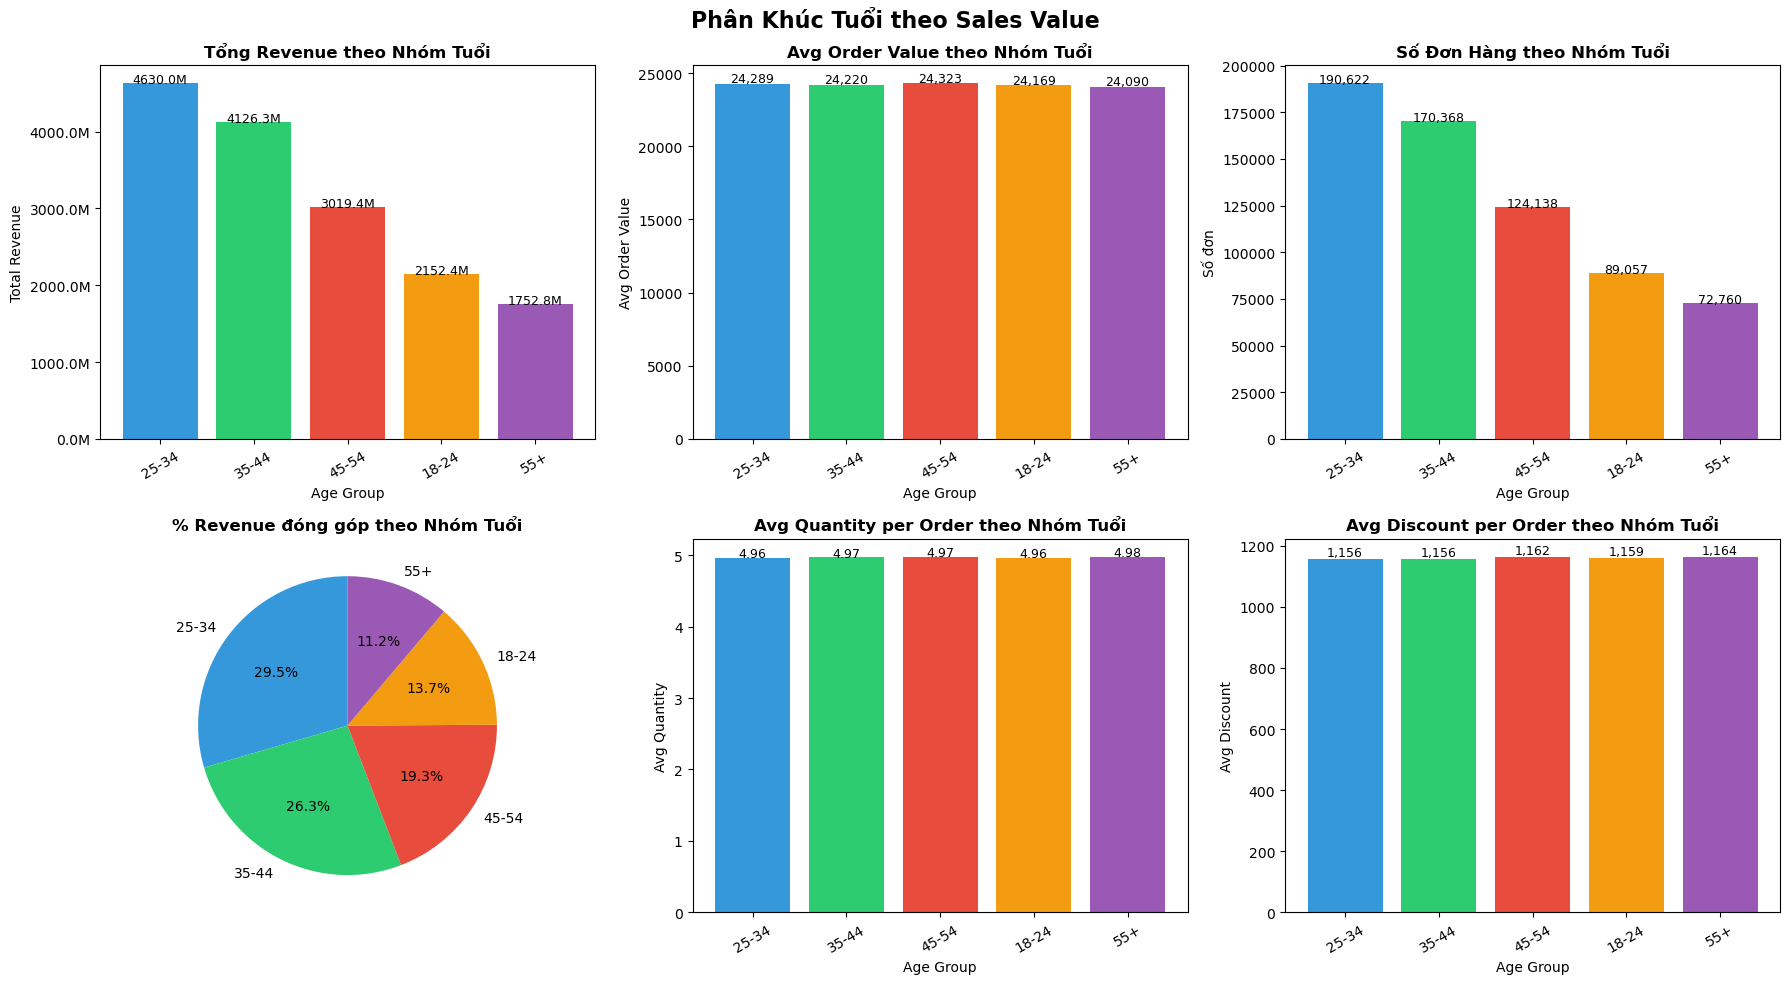

In [20]:
# ============================================================
# PHÂN KHÚC TUỔI THEO SALES VALUE
# ============================================================

# Chuẩn bị data: join orders → customers → order_items → payments
age_sales = (
    orders[['order_id', 'customer_id']]
    .merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
    .merge(payments[['order_id', 'payment_value']], on='order_id', how='left')
    .merge(order_items.groupby('order_id').agg(
        total_quantity    = ('quantity', 'sum'),
        total_discount    = ('discount_amount', 'sum'),
    ).reset_index(), on='order_id', how='left')
)

# Tổng hợp theo age_group
age_summary = age_sales.groupby('age_group').agg(
    total_revenue   = ('payment_value', 'sum'),
    avg_order_value = ('payment_value', 'mean'),
    total_orders    = ('order_id', 'count'),
    avg_quantity    = ('total_quantity', 'mean'),
    avg_discount    = ('total_discount', 'mean'),
).reset_index().sort_values('total_revenue', ascending=False)

print("=" * 60)
print("👥 PHÂN KHÚC TUỔI THEO SALES VALUE")
print("=" * 60)
print(age_summary.to_string(index=False))

# ============================================================
# VISUALIZE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phân Khúc Tuổi theo Sales Value', fontsize=16, fontweight='bold')

colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c']

# 1. Tổng Revenue theo age_group
axes[0,0].bar(age_summary['age_group'], age_summary['total_revenue'],
              color=colors[:len(age_summary)])
axes[0,0].set_title('Tổng Revenue theo Nhóm Tuổi', fontweight='bold')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Total Revenue')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
for i, v in enumerate(age_summary['total_revenue']):
    axes[0,0].text(i, v + 1000, f'{v/1e6:.1f}M', ha='center', fontsize=9)

# 2. Avg Order Value theo age_group
axes[0,1].bar(age_summary['age_group'], age_summary['avg_order_value'],
              color=colors[:len(age_summary)])
axes[0,1].set_title('Avg Order Value theo Nhóm Tuổi', fontweight='bold')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Avg Order Value')
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(age_summary['avg_order_value']):
    axes[0,1].text(i, v + 100, f'{v:,.0f}', ha='center', fontsize=9)

# 3. Số đơn hàng theo age_group
axes[0,2].bar(age_summary['age_group'], age_summary['total_orders'],
              color=colors[:len(age_summary)])
axes[0,2].set_title('Số Đơn Hàng theo Nhóm Tuổi', fontweight='bold')
axes[0,2].set_xlabel('Age Group')
axes[0,2].set_ylabel('Số đơn')
axes[0,2].tick_params(axis='x', rotation=30)
for i, v in enumerate(age_summary['total_orders']):
    axes[0,2].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# 4. % Revenue đóng góp (pie)
axes[1,0].pie(age_summary['total_revenue'],
              labels=age_summary['age_group'],
              autopct='%1.1f%%',
              colors=colors[:len(age_summary)],
              startangle=90)
axes[1,0].set_title('% Revenue đóng góp theo Nhóm Tuổi', fontweight='bold')

# 5. Avg Quantity per Order theo age_group
axes[1,1].bar(age_summary['age_group'], age_summary['avg_quantity'],
              color=colors[:len(age_summary)])
axes[1,1].set_title('Avg Quantity per Order theo Nhóm Tuổi', fontweight='bold')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Avg Quantity')
axes[1,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(age_summary['avg_quantity']):
    axes[1,1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# 6. Avg Discount theo age_group
axes[1,2].bar(age_summary['age_group'], age_summary['avg_discount'],
              color=colors[:len(age_summary)])
axes[1,2].set_title('Avg Discount per Order theo Nhóm Tuổi', fontweight='bold')
axes[1,2].set_xlabel('Age Group')
axes[1,2].set_ylabel('Avg Discount')
axes[1,2].tick_params(axis='x', rotation=30)
for i, v in enumerate(age_summary['avg_discount']):
    axes[1,2].text(i, v + 10, f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('age_group_sales.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
products.head(10)

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406
5,541,SaigonFlex UC-06,Streetwear,Everyday,M,black,16095.853846,15291.061154
6,542,SaigonFlex UC-07,Streetwear,Everyday,L,orange,9213.817742,6152.066106
7,543,SaigonFlex UC-08,Streetwear,Everyday,XL,blue,40.394178,22.487748
8,544,SaigonFlex UC-09,Streetwear,Everyday,S,white,11334.106452,8528.915105
9,545,SaigonFlex UC-10,Streetwear,Everyday,M,purple,10045.678411,9091.338962


In [23]:
city_count = geography.merge(
    customers[['zip']], on='zip', how='inner'
)['city'].value_counts().head(10)
print(city_count)
geography.info()

city
Cam Pha        4398
Thai Nguyen    4347
Phu Ly         4243
Hanoi          4240
Ha Long        4236
Bac Ninh       4172
Hai Phong      4170
Nam Dinh       4169
Bac Giang      4160
Ninh Binh      4081
Name: count, dtype: int64


In [24]:
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   zip       39948 non-null  int64   
 1   city      39948 non-null  category
 2   region    39948 non-null  category
 3   district  39948 non-null  category
dtypes: category(3), int64(1)
memory usage: 432.1 KB
